# SGD Classifier - Online Batch Learning
Train SGDClassifier using year-based batches to simulate online learning scenario

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)
import warnings

## 1. Load Prepared Data and Split

In [3]:
# Load the prepared dataset with features
ds_path = Path('.') / 'training_data_with_features.zarr'
print(f'Loading data from {ds_path}...')
ds = xr.open_dataset(ds_path, engine='zarr')
print('✓ Data loaded')

# Load the train/val/test split
split_path = Path('.') / 'data_split.npz'
print(f'\nLoading split from {split_path}...')
split_data = np.load(split_path)
train_pixel_indices = split_data['train_pixel_indices']
val_pixel_indices = split_data['val_pixel_indices']
test_pixel_indices = split_data['test_pixel_indices']
print('✓ Split loaded')

print(f'\nDataset info:')
print(f'  Total pixels: {len(ds.pixel)}')
print(f'  Total years: {len(ds.year)}')
print(f'  Train pixels: {len(train_pixel_indices)}')
print(f'  Val pixels: {len(val_pixel_indices)}')
print(f'  Test pixels: {len(test_pixel_indices)}')

Loading data from training_data_with_features.zarr...
✓ Data loaded

Loading split from data_split.npz...
✓ Split loaded

Dataset info:
  Total pixels: 8155205
  Total years: 7
  Train pixels: 5597776
  Val pixels: 1273437
  Test pixels: 1283992


## 2. Feature Engineering
Prepare features from S2 bands, spectral indices, DEM, and temporal deltas

In [4]:
def prepare_features_for_year(ds, pixel_indices, year_idx, scaler=None, scaler_mode='auto'):

    """

    Extract features for a specific year and set of pixels.

    - Skips year 0 entirely (no features returned)

    - Fills S2 band NaNs with per-pixel mean across all years

    - Drops samples that still contain NaNs (e.g., pixels where all years are NaN)

    - Filters out invalid labels (keeps only 0 and 1, removes 255)

    - Adds temporal deltas starting from year 1 (2017), where year 1 delta = 2017 - 0

    

    Scaling modes:

        - 'auto': fit scaler if needed, otherwise transform (backward-compatible)

        - 'fit': fit scaler on this batch, then transform

        - 'partial_fit': update scaler on this batch, then transform

        - 'transform': transform with an already-fitted scaler

        - 'none': return cleaned but unscaled features

    

    Args:

        ds: xarray Dataset

        pixel_indices: array of pixel indices to extract

        year_idx: year index (0-based)

        scaler: StandardScaler instance (optional)

        scaler_mode: scaling behavior mode

    

    Returns:

        X: feature matrix (scaled unless scaler_mode='none')

        y: labels (n_pixels,)

        scaler: scaler used/updated (or unchanged when scaler_mode='none')

    """

    # Skip year 0 entirely

    if year_idx == 0:

        return np.empty((0, 0)), np.empty((0,)), scaler



    valid_scaler_modes = {'auto', 'fit', 'partial_fit', 'transform', 'none'}

    if scaler_mode not in valid_scaler_modes:

        raise ValueError(f"Invalid scaler_mode '{scaler_mode}'. Valid options: {sorted(valid_scaler_modes)}")



    # Precompute per-pixel S2 means across all years for imputation

    s2_all_years = ds['s2_bands'].isel(pixel=pixel_indices).values  # (pixels, year, band)

    s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)



    # Extract data for selected pixels and target year

    ds_subset = ds.isel(pixel=pixel_indices, year=year_idx)



    # S2 bands (flatten across bands)

    s2_features = ds_subset['s2_bands'].values  # (n_pixels, n_s2_bands)

    # Fill NaNs in S2 with per-pixel mean over years

    if np.isnan(s2_features).any():

        # broadcast mean to same shape and fill

        s2_features = np.where(np.isnan(s2_features), s2_mean_per_pixel, s2_features)



    # DEM

    dem_features = ds_subset['dem'].values.reshape(-1, 1)  # (n_pixels, 1)



    # Spectral indices

    ndvi_features = ds_subset['ndvi'].values.reshape(-1, 1)

    ndwi_features = ds_subset['ndwi'].values.reshape(-1, 1)



    # Last-year features (year t-1)

    ds_prev = ds.isel(pixel=pixel_indices, year=year_idx - 1)

    ndvi_last_year = ds_prev['ndvi'].values.reshape(-1, 1)

    ndwi_last_year = ds_prev['ndwi'].values.reshape(-1, 1)

    ndvi_last_year = np.where(np.isnan(ndvi_last_year), 0, ndvi_last_year)

    ndwi_last_year = np.where(np.isnan(ndwi_last_year), 0, ndwi_last_year)



    # Last-year selected S2 bands

    required_last_year_bands = ['B04', 'B03', 'B06']

    band_to_idx = {band: i for i, band in enumerate(ds['s2_band'].values)}

    missing_bands = [band for band in required_last_year_bands if band not in band_to_idx]

    if missing_bands:

        raise ValueError(f"Missing required S2 bands for last-year features: {missing_bands}")



    last_year_s2_features = []

    for band in required_last_year_bands:

        band_values = ds_prev['s2_bands'].sel(s2_band=band).values  # (n_pixels,)

        if np.isnan(band_values).any():

            band_values = np.where(np.isnan(band_values), 0, band_values)

        last_year_s2_features.append(band_values.reshape(-1, 1))



    # Start with base features

    features_list = [

        s2_features,

        dem_features,

        ndvi_features,

        ndwi_features,

        ndvi_last_year,

        ndwi_last_year,

        *last_year_s2_features,

    ]



    # Add NBR if available

    if 'nbr' in ds.data_vars:

        nbr_features = ds_subset['nbr'].values.reshape(-1, 1)

        features_list.append(nbr_features)



    # Add temporal deltas if available

    # Delta starts from year 1: delta[0] = year[1] - 0 (2017 - 0)

    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:

        # Delta index is offset by 1: delta[0] = year[1] - 0

        delta_year_idx = year_idx - 1

        ds_delta = ds.isel(pixel=pixel_indices, year=delta_year_idx)

        ndvi_delta = ds_delta['ndvi_delta'].values.reshape(-1, 1)

        ndwi_delta = ds_delta['ndwi_delta'].values.reshape(-1, 1)

        features_list.extend([ndvi_delta, ndwi_delta])



        if 'nbr_delta' in ds.data_vars:

            nbr_delta = ds_delta['nbr_delta'].values.reshape(-1, 1)

            features_list.append(nbr_delta)



    # Add new temporal features (no data leakage - computed from prior years only)

    if 'years_since_last_disturbance' in ds.data_vars:

        years_since_features = ds_subset['years_since_last_disturbance'].values.reshape(-1, 1)

        features_list.append(years_since_features)

    

    if 'log_years_since_last_disturbance' in ds.data_vars:

        log_years_since_features = ds_subset['log_years_since_last_disturbance'].values.reshape(-1, 1)

        features_list.append(log_years_since_features)

    

    if 'ever_disturbed' in ds.data_vars:

        ever_disturbed_features = ds_subset['ever_disturbed'].values.reshape(-1, 1)

        features_list.append(ever_disturbed_features)



    # Concatenate all features

    X = np.concatenate(features_list, axis=1)



    # Labels

    y = ds_subset['disturbances'].values



    # Filter out invalid labels (keep only 0 and 1, remove 255)

    valid_label_mask = np.isin(y, [0, 1])

    X = X[valid_label_mask]

    y = y[valid_label_mask]

    

    n_invalid_labels = (~valid_label_mask).sum()

    if n_invalid_labels > 0:

        print(f'  Dropped {n_invalid_labels} samples with invalid labels (class 255) for year {year_idx}')



    # Drop samples with any remaining NaN (e.g., pixels whose all-year S2 were NaN)

    nan_mask = ~np.isnan(X).any(axis=1)

    X_clean = X[nan_mask]

    y_clean = y[nan_mask]



    n_dropped = len(X) - len(X_clean)

    if n_dropped > 0:

        print(f'  Dropped {n_dropped} samples with NaN values ({100*n_dropped/len(X):.1f}%) for year {year_idx}')



    # If nothing left, return empty arrays

    if len(X_clean) == 0:

        return np.empty((0, X.shape[1] if X.shape[0] > 0 else 0)), np.empty((0,)), scaler



    # Scaling behavior

    if scaler_mode == 'none':

        return X_clean, y_clean, scaler



    if scaler is None:

        scaler = StandardScaler()



    if scaler_mode == 'auto':

        if hasattr(scaler, 'mean_'):

            X_clean = scaler.transform(X_clean)

        else:

            X_clean = scaler.fit_transform(X_clean)

            print(f'  ✓ Fitted scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')

    elif scaler_mode == 'fit':

        X_clean = scaler.fit_transform(X_clean)

        print(f'  ✓ Fitted scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')

    elif scaler_mode == 'partial_fit':

        scaler.partial_fit(X_clean)

        X_clean = scaler.transform(X_clean)

        print(f'  ✓ Incrementally updated scaler on year {year_idx} ({len(X_clean)} samples, {X_clean.shape[1]} features)')

    elif scaler_mode == 'transform':

        if not hasattr(scaler, 'mean_'):

            raise ValueError("Scaler must be fitted before using scaler_mode='transform'.")

        X_clean = scaler.transform(X_clean)



    return X_clean, y_clean, scaler

In [4]:
# Data Overview and Diagnostic Check
print('='*80)
print('DATA OVERVIEW AND QUALITY CHECK')
print('='*80)

# 1. Dataset shape and variables
print('\n1. Dataset Structure:')
print(f'   Total pixels: {len(ds.pixel)}')
print(f'   Total years: {len(ds.year)} (values: {ds.year.values})')
print(f'   Total S2 bands: {len(ds.s2_band)} (bands: {ds.s2_band.values})')
print(f'   Variables: {list(ds.data_vars.keys())}')

# 2. Sample a subset of pixels for detailed analysis
sample_pixels = train_pixel_indices[:1000]
print(f'\n2. Analyzing {len(sample_pixels)} sample training pixels...')

# 3. Check NaN statistics per variable and year
print('\n3. NaN Statistics by Year (All Features):')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    ds_year = ds.isel(pixel=sample_pixels, year=year_idx)
    
    print(f'\n   Year {year_val} (idx={year_idx}):')
    
    # S2 bands
    s2_nan_count = np.isnan(ds_year['s2_bands'].values).sum()
    s2_total = ds_year['s2_bands'].values.size
    print(f'     S2 bands: {s2_nan_count}/{s2_total} ({100*s2_nan_count/s2_total:.1f}%) NaN')
    
    # DEM
    dem_nan_count = np.isnan(ds_year['dem'].values).sum()
    dem_total = len(sample_pixels)
    print(f'     DEM: {dem_nan_count}/{dem_total} ({100*dem_nan_count/dem_total:.1f}%) NaN')
    
    # NDVI
    ndvi_nan_count = np.isnan(ds_year['ndvi'].values).sum()
    ndvi_total = len(sample_pixels)
    print(f'     NDVI: {ndvi_nan_count}/{ndvi_total} ({100*ndvi_nan_count/ndvi_total:.1f}%) NaN')
    
    # NDWI
    ndwi_nan_count = np.isnan(ds_year['ndwi'].values).sum()
    ndwi_total = len(sample_pixels)
    print(f'     NDWI: {ndwi_nan_count}/{ndwi_total} ({100*ndwi_nan_count/ndwi_total:.1f}%) NaN')
    
    # NBR
    if 'nbr' in ds.data_vars:
        nbr_nan_count = np.isnan(ds_year['nbr'].values).sum()
        nbr_total = len(sample_pixels)
        print(f'     NBR: {nbr_nan_count}/{nbr_total} ({100*nbr_nan_count/nbr_total:.1f}%) NaN')
    
    # Temporal deltas (if available and not the first year)
    if year_idx > 0 and 'ndvi_delta' in ds.data_vars:
        ds_delta = ds.isel(pixel=sample_pixels, year=year_idx-1)
        ndvi_delta_nan_count = np.isnan(ds_delta['ndvi_delta'].values).sum()
        ndvi_delta_total = len(sample_pixels)
        print(f'     NDVI_delta: {ndvi_delta_nan_count}/{ndvi_delta_total} ({100*ndvi_delta_nan_count/ndvi_delta_total:.1f}%) NaN')
        
        ndwi_delta_nan_count = np.isnan(ds_delta['ndwi_delta'].values).sum()
        ndwi_delta_total = len(sample_pixels)
        print(f'     NDWI_delta: {ndwi_delta_nan_count}/{ndwi_delta_total} ({100*ndwi_delta_nan_count/ndwi_delta_total:.1f}%) NaN')
        
        if 'nbr_delta' in ds.data_vars:
            nbr_delta_nan_count = np.isnan(ds_delta['nbr_delta'].values).sum()
            nbr_delta_total = len(sample_pixels)
            print(f'     NBR_delta: {nbr_delta_nan_count}/{nbr_delta_total} ({100*nbr_delta_nan_count/nbr_delta_total:.1f}%) NaN')

# 4. Check S2 per-pixel mean imputation coverage
print('\n4. S2 Imputation Analysis:')
s2_all = ds['s2_bands'].isel(pixel=sample_pixels).values  # (pixels, years, bands)
s2_mean_per_pixel = np.nanmean(s2_all, axis=1)  # (pixels, band)
pixels_all_nan = np.isnan(s2_mean_per_pixel).all(axis=1).sum()
print(f'   Pixels with all-NaN S2 across all years: {pixels_all_nan}/{len(sample_pixels)} ({100*pixels_all_nan/len(sample_pixels):.1f}%)')
print(f'   These pixels will be dropped after imputation.')

# 5. Temporal delta availability
if 'ndvi_delta' in ds.data_vars:
    print('\n5. Temporal Delta Features:')
    print(f'   Delta variables available: NDVI_delta, NDWI_delta' + (', NBR_delta' if 'nbr_delta' in ds.data_vars else ''))
    print(f'   Delta has shape: {ds["ndvi_delta"].shape} (one less year than original)')

# 6. Class distribution (positive/negative percentages)
print('\n6. Disturbance Class Distribution:')
print('-' * 80)
dist_all = ds['disturbances'].isel(pixel=sample_pixels).values.flatten()
unique, counts = np.unique(dist_all, return_counts=True)
for val, count in zip(unique, counts):
    class_name = 'No Disturbance' if int(val) == 0 else 'Disturbance'
    percentage = 100 * count / len(dist_all)
    print(f'   Class {int(val)} ({class_name}): {count} ({percentage:.2f}%)')

# 7. Per-year disturbance distribution
print('\n7. Disturbance Distribution by Year:')
print('-' * 80)
for year_idx in range(len(ds.year)):
    year_val = ds.year.values[year_idx]
    dist_year = ds['disturbances'].isel(pixel=sample_pixels, year=year_idx).values
    class_0_count = (dist_year == 0).sum()
    class_1_count = (dist_year == 1).sum()
    total = len(dist_year)
    print(f'   Year {year_val}:')
    print(f'     No Disturbance: {class_0_count}/{total} ({100*class_0_count/total:.2f}%)')
    print(f'     Disturbance: {class_1_count}/{total} ({100*class_1_count/total:.2f}%)')

# 8. Test one year in detail (year 1)
print('\n8. Detailed Check for Year 1:')
ds_y1 = ds.isel(pixel=sample_pixels, year=1)
s2_y1 = ds_y1['s2_bands'].values
dem_y1 = ds_y1['dem'].values
ndvi_y1 = ds_y1['ndvi'].values
ndwi_y1 = ds_y1['ndwi'].values

# After imputation simulation
s2_y1_imputed = np.where(np.isnan(s2_y1), s2_mean_per_pixel, s2_y1)
all_features_y1 = np.concatenate([
    s2_y1_imputed, 
    dem_y1.reshape(-1, 1), 
    ndvi_y1.reshape(-1, 1),
    ndwi_y1.reshape(-1, 1)
], axis=1)

nan_mask_y1 = ~np.isnan(all_features_y1).any(axis=1)
remaining_y1 = nan_mask_y1.sum()
dropped_y1 = len(sample_pixels) - remaining_y1

print(f'   After S2 imputation: {remaining_y1}/{len(sample_pixels)} samples remain ({100*remaining_y1/len(sample_pixels):.1f}%)')
print(f'   Would drop: {dropped_y1} samples ({100*dropped_y1/len(sample_pixels):.1f}%)')

print('\n' + '='*80)
print('✓ Data overview complete. Review statistics before training.')
print('='*80)

DATA OVERVIEW AND QUALITY CHECK

1. Dataset Structure:
   Total pixels: 8155205
   Total years: 7 (values: [2016 2017 2018 2019 2020 2021 2022])
   Total S2 bands: 7 (bands: ['B02' 'B03' 'B04' 'B05' 'B06' 'B07' 'B8A'])
   Variables: ['cube_idx', 'cube_name', 'dem', 'disturbances', 'ever_disturbed', 'log_years_since_last_disturbance', 'nbr', 'nbr_delta', 'ndvi', 'ndvi_delta', 'ndwi', 'ndwi_delta', 's2_bands', 'x', 'y', 'year_disturbance', 'years_since_last_disturbance']

2. Analyzing 1000 sample training pixels...

3. NaN Statistics by Year (All Features):
--------------------------------------------------------------------------------

   Year 2016 (idx=0):
     S2 bands: 7000/7000 (100.0%) NaN
     DEM: 0/1000 (0.0%) NaN
     NDVI: 1000/1000 (100.0%) NaN
     NDWI: 1000/1000 (100.0%) NaN
     NBR: 1000/1000 (100.0%) NaN

   Year 2017 (idx=1):
     S2 bands: 0/7000 (0.0%) NaN
     DEM: 0/1000 (0.0%) NaN
     NDVI: 0/1000 (0.0%) NaN
     NDWI: 0/1000 (0.0%) NaN
     NBR: 0/1000 (0.0%) N

## 3. Initialize SGD Classifier

In [5]:
from sklearn.utils.class_weight import compute_class_weight



# Compute class weights from the full training data

# Sample across all years to get representative class distribution

print('Computing class weights from training data...')

all_train_labels = []

for year_idx in range(1, len(ds.year)):

    _, y_batch, _ = prepare_features_for_year(

        ds,

        train_pixel_indices,

        year_idx,

        scaler=None,

        scaler_mode='none'

    )

    if len(y_batch) > 0:

        all_train_labels.extend(y_batch)



all_train_labels = np.array(all_train_labels)

initial_count = len(all_train_labels)



# Remove any NaN values and convert to int

all_train_labels = all_train_labels[~np.isnan(all_train_labels)].astype(int)

after_nan_removal = len(all_train_labels)

nan_removed = initial_count - after_nan_removal



# Filter out invalid class 255 (keep only 0 and 1)

valid_mask = np.isin(all_train_labels, [0, 1])

all_train_labels = all_train_labels[valid_mask]

after_class_filter = len(all_train_labels)

class_255_removed = after_nan_removal - after_class_filter



print(f'\nLabel filtering summary:')

print(f'  Initial labels: {initial_count}')

print(f'  Removed NaN: {nan_removed}')

print(f'  Removed class 255: {class_255_removed}')

print(f'  Final valid labels: {after_class_filter}')



if len(all_train_labels) == 0:

    raise ValueError('No valid training labels after filtering! Check data quality.')



classes = np.array([0, 1])



print(f'\nCollected {len(all_train_labels)} training labels')

print(f'Unique classes in data: {np.unique(all_train_labels)}')



# Compute balanced class weights

class_weights_array = compute_class_weight('balanced', classes=classes, y=all_train_labels)

class_weight_dict = {classes[i]: class_weights_array[i] for i in range(len(classes))}



print(f'\nClass weights computed:')

print(f'  Class 0 (no disturbance): {class_weight_dict[0]:.4f}')

print(f'  Class 1 (disturbance): {class_weight_dict[1]:.4f}')

print(f'  Ratio (1:0): {class_weight_dict[1]/class_weight_dict[0]:.2f}x')



# Initialize SGD Classifier WITHOUT class_weight (not supported by partial_fit)

model = SGDClassifier(

    loss='log_loss',              # Logistic regression (gives probabilities)

    penalty='l2',                 # L2 regularization

    alpha=0.0001,                 # Regularization strength

    random_state=42,

    n_jobs=-1,                    # Use all CPU cores

    learning_rate='optimal',      # Optimal learning rate

    max_iter=1000,                # Max iterations per partial_fit

    tol=1e-3,                     # Tolerance for stopping

    warm_start=False,             # Don't preserve state between calls

    verbose=0

)



print(f'\n✓ SGD Classifier initialized with settings:')

print(f'  Loss: {model.loss}')

print(f'  Penalty: {model.penalty}')

print(f'  Class weights: Will be applied via sample_weight in partial_fit')

print(f'  Learning rate: {model.learning_rate}')

Computing class weights from training data...


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 8827 samples with NaN values (0.2%) for year 1
  Dropped 727 samples with invalid labels (class 255) for year 2
  Dropped 8517 samples with NaN values (0.2%) for year 2
  Dropped 727 samples with invalid labels (class 255) for year 3
  Dropped 8671 samples with NaN values (0.2%) for year 3
  Dropped 727 samples with invalid labels (class 255) for year 4
  Dropped 7824 samples with NaN values (0.1%) for year 4
  Dropped 727 samples with invalid labels (class 255) for year 5
  Dropped 8487 samples with NaN values (0.2%) for year 5
  Dropped 727 samples with invalid labels (class 255) for year 6
  Dropped 4687 samples with NaN values (0.1%) for year 6

Label filtering summary:
  Initial labels: 33535281
  Removed NaN: 0
  Removed class 255: 0
  Final valid labels: 33535281

Collected 33535281 training labels
Unique classes in data: [0 1]

Class weights computed:
  Class 0 (no disturbance): 0.5105
  Class 1 (disturb

## 4. Online Training Loop (Year-by-Year Batches)

In [6]:
import pickle

import copy

from pathlib import Path



OUTPUT_SUFFIX = 'incremental_scaler'

MODELS_DIR_NAME = f'models_lagged_features_{OUTPUT_SUFFIX}'

SCALER_FILE_TEMPLATE = f'scaler_year_{{year}}_lagged_features_{OUTPUT_SUFFIX}.pkl'

MODEL_FILE_TEMPLATE = f'model_year_{{year}}_lagged_features_{OUTPUT_SUFFIX}.pkl'

FINAL_SCALER_FILENAME = f'scaler_final_lagged_features_{OUTPUT_SUFFIX}.pkl'



# Create models directory if it doesn't exist

models_dir = Path('.') / MODELS_DIR_NAME

models_dir.mkdir(exist_ok=True)

print(f'✓ Models directory: {models_dir.absolute()}')

print(f'✓ Scaler file pattern: {SCALER_FILE_TEMPLATE}')

print(f'✓ Model file pattern: {MODEL_FILE_TEMPLATE}')


✓ Models directory: c:\Users\bartu\Desktop\Fonda-scikit\models_lagged_features_incremental_scaler
✓ Scaler file pattern: scaler_year_{year}_lagged_features_incremental_scaler.pkl
✓ Model file pattern: model_year_{year}_lagged_features_incremental_scaler.pkl


In [7]:
# Training history tracking

training_history = {

    'year': [],

    'train_accuracy': [],

    'train_precision': [],

    'train_recall': [],

    'train_f1': [],

    'val_accuracy': [],

    'val_precision': [],

    'val_recall': [],

    'val_f1': [],

    'val_roc_auc': [],

    'val_pr_auc': []

}



n_years = len(ds.year)

year_values = ds.year.values



# Use one running scaler and update it incrementally year-by-year

print('Using incremental scaler: one running scaler updated year-by-year and checkpointed per year.')

incremental_scaler = StandardScaler()

year_to_scaler_checkpoint = {}



# Mini-batch and multi-epoch training configuration

CHUNK_SIZE = 50000  # Mini-batch size

MAX_EPOCHS = 15     # Maximum epochs per year

PATIENCE = 3        # Early stopping patience (epochs)

MIN_DELTA = 0.0005  # Minimum improvement in PR-AUC to reset patience



print(f'Training Configuration:')

print(f'  Chunk size: {CHUNK_SIZE:,} samples')

print(f'  Max epochs per year: {MAX_EPOCHS}')

print(f'  Early stopping patience: {PATIENCE} epochs')

print(f'  Min PR-AUC improvement: {MIN_DELTA}\n')



print(f'Starting online training with years 1..{n_years-1} (year 0 skipped)...\n')



for year_idx in tqdm(range(1, n_years), desc='Training by year'):

    year_val = year_values[year_idx]



    # Prepare training batch and incrementally update scaler using this year's training data

    X_train_batch, y_train_batch, incremental_scaler = prepare_features_for_year(

        ds,

        train_pixel_indices,

        year_idx,

        scaler=incremental_scaler,

        scaler_mode='partial_fit'

    )



    # Prepare validation data using the same scaler state as this year model

    X_val_batch, y_val_batch, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        year_idx,

        scaler=incremental_scaler,

        scaler_mode='transform'

    )



    # Skip if no data available for this year

    if len(X_train_batch) == 0 or len(X_val_batch) == 0:

        print(f'Year {year_val}: skipped (no samples after NaN handling)')

        continue



    # Persist scaler checkpoint for this year

    scaler_checkpoint = copy.deepcopy(incremental_scaler)

    year_to_scaler_checkpoint[year_val] = scaler_checkpoint

    year_scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    with open(year_scaler_path, 'wb') as f:

        pickle.dump(scaler_checkpoint, f)

    print(f'  ✓ Incremental scaler checkpoint saved to {year_scaler_path.name}')



    # Split training batch into chunks

    n_samples = len(X_train_batch)

    n_chunks = max(1, int(np.ceil(n_samples / CHUNK_SIZE)))



    # Track best validation PR-AUC for early stopping

    best_val_pr_auc = -np.inf

    patience_counter = 0

    best_model_state = None



    print(f'\nYear {year_val}: {n_samples:,} samples, {n_chunks} chunks')



    # Multi-epoch training

    for epoch in range(MAX_EPOCHS):

        # Shuffle indices for this epoch

        shuffle_idx = np.random.permutation(n_samples)

        X_train_shuffled = X_train_batch[shuffle_idx]

        y_train_shuffled = y_train_batch[shuffle_idx]



        # Process chunks

        for chunk_idx in range(n_chunks):

            start_idx = chunk_idx * CHUNK_SIZE

            end_idx = min(start_idx + CHUNK_SIZE, n_samples)



            X_chunk = X_train_shuffled[start_idx:end_idx]

            y_chunk = y_train_shuffled[start_idx:end_idx]



            # Compute sample weights for this chunk

            sample_weights_chunk = np.array([class_weight_dict[int(label)] for label in y_chunk])



            # Incremental fit on chunk

            classes = np.array([0, 1])

            model.partial_fit(X_chunk, y_chunk, classes=classes, sample_weight=sample_weights_chunk)



        # Evaluate on validation after each epoch

        y_val_pred = model.predict(X_val_batch)

        y_val_proba = model.predict_proba(X_val_batch)[:, 1]



        val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)

        val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)

        val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)



        if len(np.unique(y_val_batch)) > 1:

            val_pr_auc = average_precision_score(y_val_batch, y_val_proba)

        else:

            val_pr_auc = np.nan



        # Early stopping check

        if val_pr_auc > best_val_pr_auc + MIN_DELTA:

            best_val_pr_auc = val_pr_auc

            patience_counter = 0

            # Save best model state

            best_model_state = {

                'coef': model.coef_.copy(),

                'intercept': model.intercept_.copy(),

                't_': model.t_

            }

            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} ✓ (improved)')

        else:

            patience_counter += 1

            print(f'  Epoch {epoch+1}/{MAX_EPOCHS}: Val PR-AUC={val_pr_auc:.4f} (no improvement, patience={patience_counter}/{PATIENCE})')



            if patience_counter >= PATIENCE:

                print(f'  Early stopping triggered. Restoring best model.')

                # Restore best model state

                if best_model_state is not None:

                    model.coef_ = best_model_state['coef']

                    model.intercept_ = best_model_state['intercept']

                    model.t_ = best_model_state['t_']

                break



    # Final evaluation on training and validation

    y_train_pred = model.predict(X_train_batch)

    train_acc = accuracy_score(y_train_batch, y_train_pred)

    train_prec = precision_score(y_train_batch, y_train_pred, zero_division=0)

    train_rec = recall_score(y_train_batch, y_train_pred, zero_division=0)

    train_f1 = f1_score(y_train_batch, y_train_pred, zero_division=0)



    y_val_pred = model.predict(X_val_batch)

    y_val_proba = model.predict_proba(X_val_batch)[:, 1]

    val_acc = accuracy_score(y_val_batch, y_val_pred)

    val_prec = precision_score(y_val_batch, y_val_pred, zero_division=0)

    val_rec = recall_score(y_val_batch, y_val_pred, zero_division=0)

    val_f1 = f1_score(y_val_batch, y_val_pred, zero_division=0)



    if len(np.unique(y_val_batch)) > 1:

        val_roc_auc = roc_auc_score(y_val_batch, y_val_proba)

        val_pr_auc = average_precision_score(y_val_batch, y_val_proba)

    else:

        val_roc_auc = np.nan

        val_pr_auc = np.nan



    # Store metrics

    training_history['year'].append(year_val)

    training_history['train_accuracy'].append(train_acc)

    training_history['train_precision'].append(train_prec)

    training_history['train_recall'].append(train_rec)

    training_history['train_f1'].append(train_f1)

    training_history['val_accuracy'].append(val_acc)

    training_history['val_precision'].append(val_prec)

    training_history['val_recall'].append(val_rec)

    training_history['val_f1'].append(val_f1)

    training_history['val_roc_auc'].append(val_roc_auc)

    training_history['val_pr_auc'].append(val_pr_auc)



    # Save model for this year

    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    with open(year_model_path, 'wb') as f:

        pickle.dump(model, f)



    # Print summary for this year

    print(

        f'  Final: Train F1={train_f1:.3f}, Val F1={val_f1:.3f}, '

        f'Val Precision={val_prec:.3f}, Val Recall={val_rec:.3f}, Val PR-AUC={val_pr_auc:.3f}'

    )

    print(f'  ✓ Model saved to {year_model_path.name}')



if hasattr(incremental_scaler, 'mean_'):

    final_scaler_path = models_dir / FINAL_SCALER_FILENAME

    with open(final_scaler_path, 'wb') as f:

        pickle.dump(incremental_scaler, f)

    print(f'✓ Final incremental scaler saved to {final_scaler_path.name}')



print('\n✓ Training complete!')


Using incremental scaler: one running scaler updated year-by-year and checkpointed per year.
Training Configuration:
  Chunk size: 50,000 samples
  Max epochs per year: 15
  Early stopping patience: 3 epochs
  Min PR-AUC improvement: 0.0005

Starting online training with years 1..6 (year 0 skipped)...



Training by year:   0%|          | 0/6 [00:00<?, ?it/s]

C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 8827 samples with NaN values (0.2%) for year 1
  ✓ Incrementally updated scaler on year 1 (5588222 samples, 22 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


...

  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1433 samples with NaN values (0.1%) for year 5
  ✓ Incremental scaler checkpoint saved to scaler_year_2021_lagged_features_incremental_scaler.pkl

Year 2021: 5,588,562 samples, 112 chunks
  Epoch 1/15: Val PR-AUC=0.3650 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.3628 (no improvement, patience=1/3)
  Epoch 3/15: Val PR-AUC=0.3607 (no improvement, patience=2/3)
  Epoch 4/15: Val PR-AUC=0.3633 (no improvement, patience=3/3)
  Early stopping triggered. Restoring best model.
  Final: Train F1=0.169, Val F1=0.166, Val Precision=0.094, Val Recall=0.722, Val PR-AUC=0.365
  ✓ Model saved to model_year_2021_lagged_features_incremental_scaler.pkl


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 6
  Dropped 4687 samples with NaN values (0.1%) for year 6
  ✓ Incrementally updated scaler on year 6 (5592362 samples, 22 features)


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 682 samples with NaN values (0.1%) for year 6
  ✓ Incremental scaler checkpoint saved to scaler_year_2022_lagged_features_incremental_scaler.pkl

Year 2022: 5,592,362 samples, 112 chunks
  Epoch 1/15: Val PR-AUC=0.2762 ✓ (improved)
  Epoch 2/15: Val PR-AUC=0.2726 (no improvement, patience=1/3)
  Epoch 3/15: Val PR-AUC=0.2701 (no improvement, patience=2/3)
  Epoch 4/15: Val PR-AUC=0.2775 ✓ (improved)
  Epoch 5/15: Val PR-AUC=0.2745 (no improvement, patience=1/3)
  Epoch 6/15: Val PR-AUC=0.2679 (no improvement, patience=2/3)
  Epoch 7/15: Val PR-AUC=0.2753 (no improvement, patience=3/3)
  Early stopping triggered. Restoring best model.
  Final: Train F1=0.174, Val F1=0.154, Val Precision=0.085, Val Recall=0.772, Val PR-AUC=0.278
  ✓ Model saved to model_year_2022_lagged_features_incremental_scaler.pkl
✓ Final incremental scaler saved to scaler_final_lagged_features_incremental_scaler.pkl

✓ Training complete!


## 5. Visualize Learning Progress

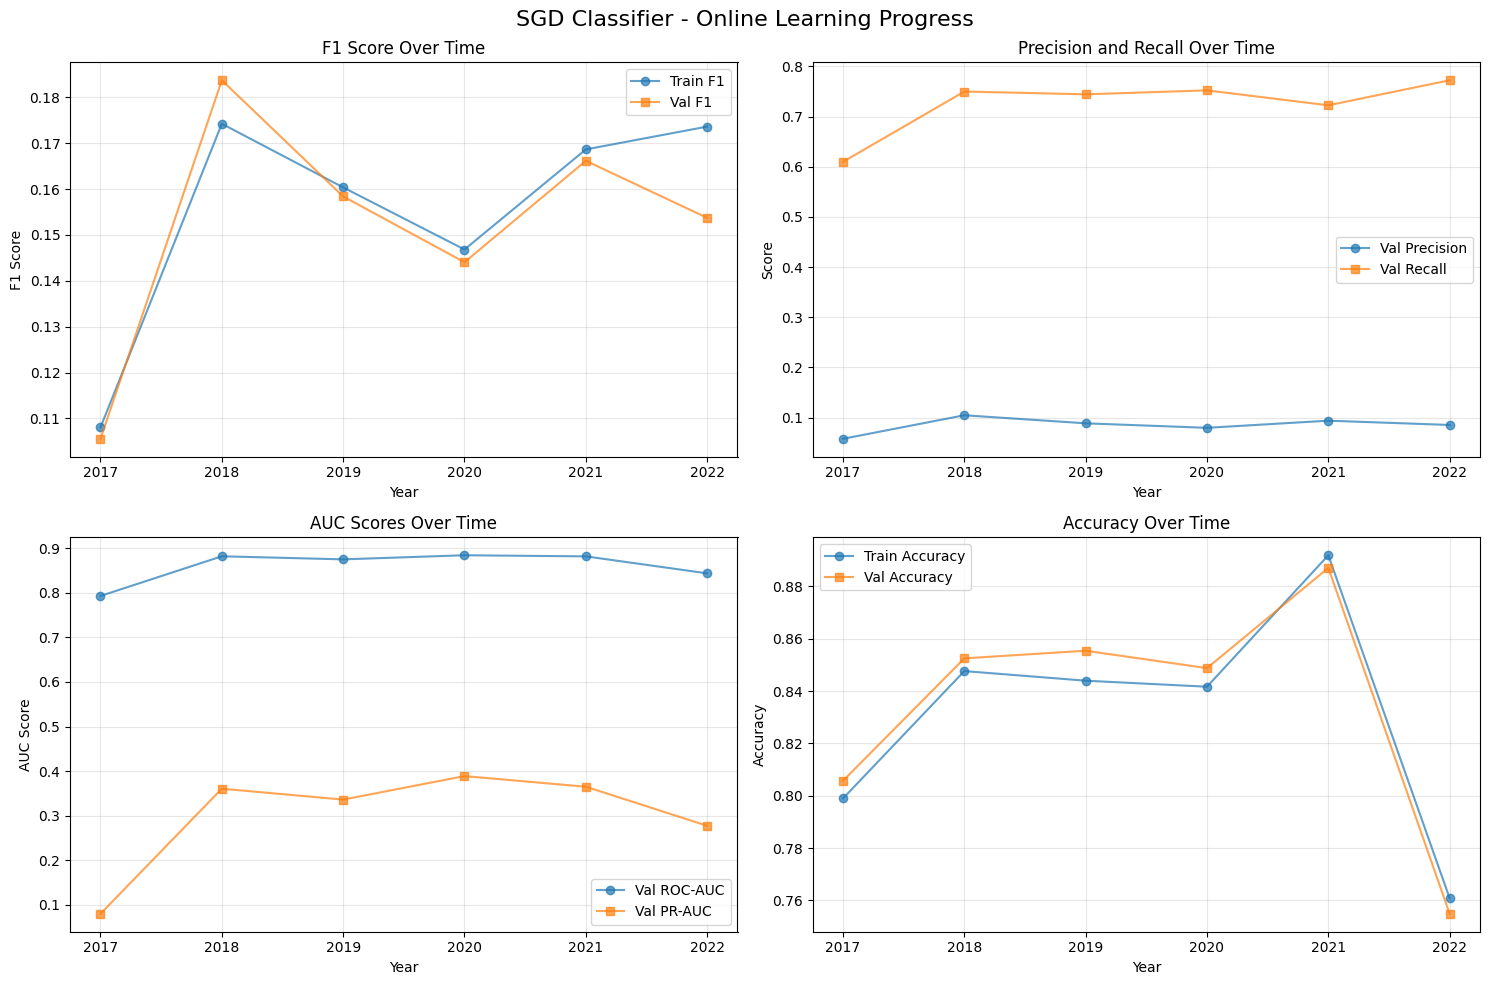


Summary Statistics (Validation Set):
       val_accuracy  val_precision  val_recall    val_f1  val_roc_auc  \
count      6.000000       6.000000    6.000000  6.000000     6.000000   
mean       0.834079       0.085002    0.725207  0.151945     0.859572   
std        0.046695       0.015804    0.058748  0.026344     0.036111   
min        0.754878       0.057788    0.609826  0.105573     0.792641   
25%        0.816495       0.081084    0.727946  0.146479     0.851167   
50%        0.850660       0.086999    0.747144  0.156072     0.878028   
75%        0.854710       0.092569    0.751675  0.164228     0.881503   
max        0.887111       0.104688    0.772393  0.183728     0.883859   

       val_pr_auc  
count    6.000000  
mean     0.301394  
std      0.114818  
min      0.080192  
25%      0.292176  
50%      0.348382  
75%      0.363925  
max      0.388862  


In [8]:
# Convert history to DataFrame
history_df = pd.DataFrame(training_history)

# Plot learning curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SGD Classifier - Online Learning Progress', fontsize=16)

# Plot 1: F1 Score
ax = axes[0, 0]
ax.plot(history_df['year'], history_df['train_f1'], label='Train F1', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_f1'], label='Val F1', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Precision and Recall
ax = axes[0, 1]
ax.plot(history_df['year'], history_df['val_precision'], label='Val Precision', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_recall'], label='Val Recall', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: ROC-AUC and PR-AUC
ax = axes[1, 0]
ax.plot(history_df['year'], history_df['val_roc_auc'], label='Val ROC-AUC', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_pr_auc'], label='Val PR-AUC', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('AUC Score')
ax.set_title('AUC Scores Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Accuracy
ax = axes[1, 1]
ax.plot(history_df['year'], history_df['train_accuracy'], label='Train Accuracy', marker='o', alpha=0.7)
ax.plot(history_df['year'], history_df['val_accuracy'], label='Val Accuracy', marker='s', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display summary statistics
print('\nSummary Statistics (Validation Set):')
print(history_df[['val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_roc_auc', 'val_pr_auc']].describe())

## 6. Final Evaluation on Test Set

In [9]:
# Evaluate on entire test set (years 1..end, year 0 skipped) with incremental scaler checkpoints

print('Evaluating on test set...')



decision_threshold = float(globals().get('best_threshold', 0.5))

print(f'Using decision threshold: {decision_threshold:.4f}\n')



y_test_all = []

y_pred_all = []

y_proba_all = []



for year_idx in range(1, n_years):

    year_val = year_values[year_idx]



    # Load year-specific scaler checkpoint

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():

        with open(scaler_path, 'rb') as f:

            year_scaler = pickle.load(f)

    else:

        # Fallback to in-memory scaler checkpoints (if training ran in this session)

        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)



    if year_scaler is None:

        print(f'Year {year_val}: scaler checkpoint not found, skipping this year in test evaluation.')

        continue



    # Prepare test data for this year using its scaler checkpoint

    X_test_year, y_test_year, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )

    if len(X_test_year) == 0:

        print(f'Year {year_val}: skipped in test (no samples after NaN handling)')

        continue



    # Predictions for this year

    y_proba_year = model.predict_proba(X_test_year)[:, 1]

    y_pred_year = (y_proba_year >= decision_threshold).astype(int)



    # Accumulate

    y_test_all.append(y_test_year)

    y_pred_all.append(y_pred_year)

    y_proba_all.append(y_proba_year)



# Combine all years

if len(y_test_all) == 0:

    raise ValueError('No test samples available after NaN handling. Consider adjusting preprocessing.')



y_test = np.concatenate(y_test_all)

y_test_pred = np.concatenate(y_pred_all)

y_test_proba = np.concatenate(y_proba_all)



print(f'Test set size: {y_test.shape[0]} samples')



# Metrics

test_acc = accuracy_score(y_test, y_test_pred)

test_prec = precision_score(y_test, y_test_pred, zero_division=0)

test_rec = recall_score(y_test, y_test_pred, zero_division=0)

test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

test_roc_auc = roc_auc_score(y_test, y_test_proba)

test_pr_auc = average_precision_score(y_test, y_test_proba)



print('\n=== TEST SET RESULTS ===')

print(f'Threshold: {decision_threshold:.4f}')

print(f'Accuracy:  {test_acc:.4f}')

print(f'Precision: {test_prec:.4f}')

print(f'Recall:    {test_rec:.4f}')

print(f'F1 Score:  {test_f1:.4f}')

print(f'ROC-AUC:   {test_roc_auc:.4f}')

print(f'PR-AUC:    {test_pr_auc:.4f}')



# Confusion Matrix

cm = confusion_matrix(y_test, y_test_pred)

print('\nConfusion Matrix:')

print(cm)

print(f'\nTrue Negatives:  {cm[0, 0]}')

print(f'False Positives: {cm[0, 1]}')

print(f'False Negatives: {cm[1, 0]}')

print(f'True Positives:  {cm[1, 1]}')



# Classification Report

print('\nClassification Report:')

print(classification_report(y_test, y_test_pred, target_names=['No Disturbance', 'Disturbance']))


Evaluating on test set...
Using decision threshold: 0.5000



C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2031 samples with NaN values (0.2%) for year 2


...

  Dropped 291 samples with invalid labels (class 255) for year 4
  Dropped 1876 samples with NaN values (0.1%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2098 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6
Test set size: 7690802 samples

=== TEST SET RESULTS ===
Threshold: 0.5000
Accuracy:  0.6439
Precision: 0.0495
Recall:    0.8215
F1 Score:  0.0935
ROC-AUC:   0.8267
PR-AUC:    0.2920

Confusion Matrix:
[[4811136 2707830]
 [  30677  141159]]

True Negatives:  4811136
False Positives: 2707830
False Negatives: 30677
True Positives:  141159

Classification Report:
                precision    recall  f1-score   support

No Disturbance       0.99      0.64      0.78   7518966
   Disturbance       0.05      0.82      0.09    171836

      accuracy                           0.64   7690802
     macro avg       0.52      0.73      0.44   7690802
  weighted avg       0.97      0.64      0.76   7690802



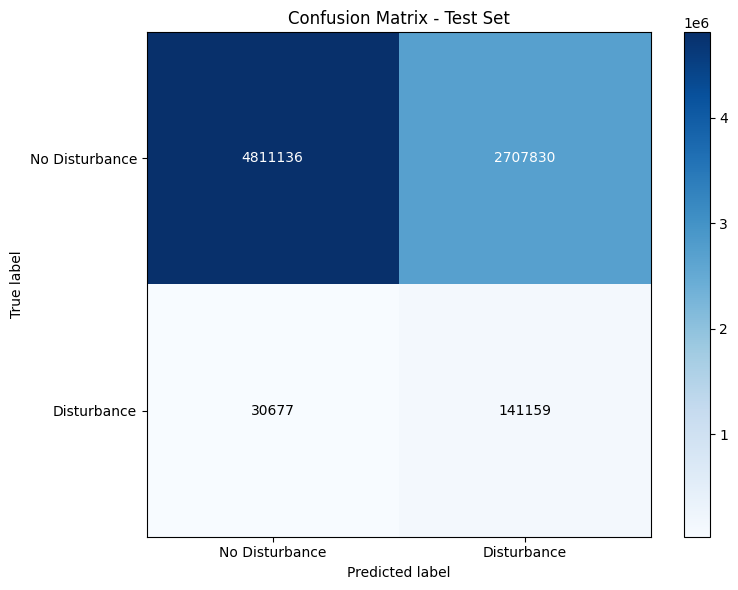

In [10]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['No Disturbance', 'Disturbance'],
       yticklabels=['No Disturbance', 'Disturbance'],
       title='Confusion Matrix - Test Set',
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import precision_recall_curve



print('='*80)

print('DYNAMIC THRESHOLD SELECTION (Validation PR Curve)')

print('='*80)



# Collect validation probabilities across years using saved scaler checkpoints

y_val_all = []

y_val_proba_all = []

for year_idx in range(1, n_years):

    year_val = year_values[year_idx]

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():

        with open(scaler_path, 'rb') as f:

            year_scaler = pickle.load(f)

    else:

        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)

    if year_scaler is None:

        continue

    X_val_year, y_val_year, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )

    if len(X_val_year) == 0:

        continue

    y_val_all.append(y_val_year)

    y_val_proba_all.append(model.predict_proba(X_val_year)[:, 1])



if len(y_val_all) == 0:

    raise ValueError('No validation samples available for threshold tuning.')



# Concatenate validation labels and probabilities

y_val_concat = np.concatenate(y_val_all)

y_val_proba_concat = np.concatenate(y_val_proba_all)



# Validation PR curve and AUPRC

val_pr_auc = average_precision_score(y_val_concat, y_val_proba_concat)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_concat, y_val_proba_concat)

f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)

best_idx = f1_vals.argmax()

best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5



print(f'Validation AUPRC: {val_pr_auc:.4f}')

print(f'Best threshold (max F1 on PR curve): {best_threshold:.4f}')

print(f'  Precision={precision_vals[best_idx]:.4f}, Recall={recall_vals[best_idx]:.4f}, F1={f1_vals[best_idx]:.4f}')



# Apply dynamic threshold to test set probabilities already computed

y_test_pred_dyn = (y_test_proba >= best_threshold).astype(int)

dyn_cm = confusion_matrix(y_test, y_test_pred_dyn)

tn, fp, fn, tp = dyn_cm.ravel()

dyn_fp_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan



# Test metrics with dynamic threshold

test_acc_dyn = accuracy_score(y_test, y_test_pred_dyn)

test_prec_dyn = precision_score(y_test, y_test_pred_dyn, zero_division=0)

test_rec_dyn = recall_score(y_test, y_test_pred_dyn, zero_division=0)

test_f1_dyn = f1_score(y_test, y_test_pred_dyn, zero_division=0)

test_pr_auc_dyn = average_precision_score(y_test, y_test_proba)



print('\n=== TEST SET WITH DYNAMIC THRESHOLD ===')

print(f'Threshold: {best_threshold:.4f}')

print(f'Accuracy:  {test_acc_dyn:.4f}')

print(f'Precision: {test_prec_dyn:.4f}')

print(f'Recall:    {test_rec_dyn:.4f}')

print(f'F1 Score:  {test_f1_dyn:.4f}')

print(f'False Positive Rate: {dyn_fp_rate:.4f}')

print('Confusion Matrix:')

print(dyn_cm)


DYNAMIC THRESHOLD SELECTION (Validation PR Curve)


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 1324 samples with NaN values (0.1%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 2
  Dropped 1292 samples with NaN values (0.1%) for year 2


...

  Dropped 101 samples with invalid labels (class 255) for year 4
  Dropped 1365 samples with NaN values (0.1%) for year 4


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 5
  Dropped 1433 samples with NaN values (0.1%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 682 samples with NaN values (0.1%) for year 6
Validation AUPRC: 0.2604
Best threshold (max F1 on PR curve): 0.9617
  Precision=0.3729, Recall=0.2734, F1=0.3155

=== TEST SET WITH DYNAMIC THRESHOLD ===
Threshold: 0.9617
Accuracy:  0.9732
Precision: 0.3738
Recall:    0.2986
F1 Score:  0.3320
False Positive Rate: 0.0114
Confusion Matrix:
[[7432997   85969]
 [ 120519   51317]]


## 7. Save Model and Results

In [12]:
import pickle



# Save the trained model

model_path = Path('.') / 'sgd_classifier_model_lagged_features_incremental_scaler.pkl'

with open(model_path, 'wb') as f:

    pickle.dump(model, f)

print(f'✓ Model saved to {model_path}')



# Save final incremental scaler (same state as latest year checkpoint)

if 'incremental_scaler' in globals() and hasattr(incremental_scaler, 'mean_'):

    final_scaler_path = models_dir / FINAL_SCALER_FILENAME

    with open(final_scaler_path, 'wb') as f:

        pickle.dump(incremental_scaler, f)

    print(f'✓ Final scaler saved to {final_scaler_path}')



# Per-year scaler checkpoints are already saved under models_dir

print(f'✓ Per-year scaler checkpoints saved under {models_dir} ({SCALER_FILE_TEMPLATE})')



# Save training history

history_path = Path('.') / 'sgd_classifier_history_lagged_features_incremental_scaler.csv'

history_df.to_csv(history_path, index=False)

print(f'✓ Training history saved to {history_path}')



# Save test results

test_results = {

    'accuracy': test_acc,

    'precision': test_prec,

    'recall': test_rec,

    'f1_score': test_f1,

    'roc_auc': test_roc_auc,

    'pr_auc': test_pr_auc,

    'confusion_matrix': cm.tolist()

}



results_path = Path('.') / 'sgd_classifier_test_results_lagged_features_incremental_scaler.json'

import json

with open(results_path, 'w') as f:

    json.dump(test_results, f, indent=2)

print(f'✓ Test results saved to {results_path}')


✓ Model saved to sgd_classifier_model_lagged_features_incremental_scaler.pkl
✓ Final scaler saved to models_lagged_features_incremental_scaler\scaler_final_lagged_features_incremental_scaler.pkl
✓ Per-year scaler checkpoints saved under models_lagged_features_incremental_scaler (scaler_year_{year}_lagged_features_incremental_scaler.pkl)
✓ Training history saved to sgd_classifier_history_lagged_features_incremental_scaler.csv
✓ Test results saved to sgd_classifier_test_results_lagged_features_incremental_scaler.json


## 8. Feature Importance Analysis


Top 15 Most Important Features:


,Feature,Coefficient,Abs_Coefficient
8,NDVI,-4.333435,4.333435
10,NDVI_last_year,3.044635,3.044635
16,NDVI_delta,-3.022322,3.022322
9,NDWI,-2.874690,2.874690
13,S2_B03_last_year,2.179550,2.179550
2,S2_B04,-2.005548,2.005548
20,log_years_since_last_disturbance,1.753678,1.753678
11,NDWI_last_year,-1.608191,1.608191
3,S2_B05,1.418391,1.418391
17,NDWI_delta,-1.317984,1.317984


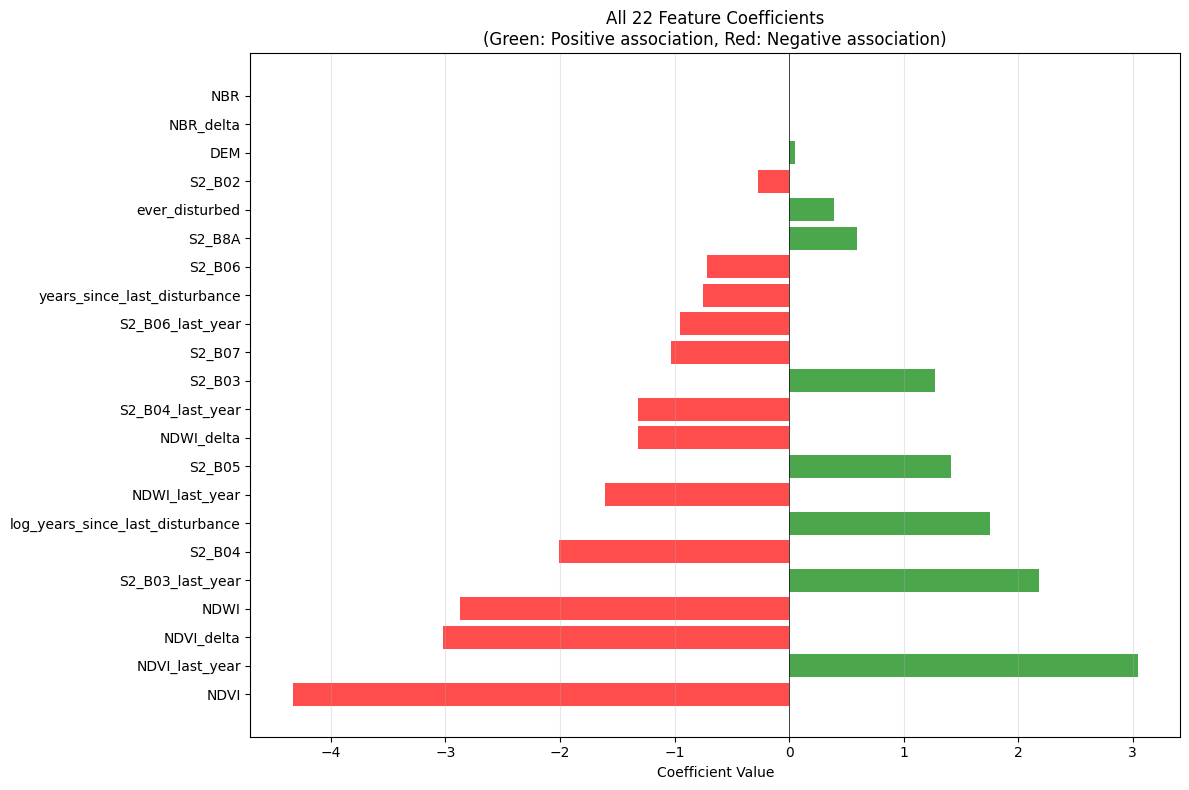

In [13]:
# Extract feature coefficients from the model
coefficients = model.coef_[0]

# Create feature names
s2_bands = ds['s2_band'].values
feature_names = [f'S2_{band}' for band in s2_bands]
feature_names.extend(['DEM', 'NDVI', 'NDWI'])
feature_names.extend([
    'NDVI_last_year',
    'NDWI_last_year',
    'S2_B04_last_year',
    'S2_B03_last_year',
    'S2_B06_last_year',
])
if 'nbr' in ds.data_vars:
    feature_names.append('NBR')
# Note: temporal deltas only for year > 0, but averaged in coefficients
if 'ndvi_delta' in ds.data_vars:
    feature_names.extend(['NDVI_delta', 'NDWI_delta'])
    if 'nbr_delta' in ds.data_vars:
        feature_names.append('NBR_delta')

# New temporal features
if 'years_since_last_disturbance' in ds.data_vars:
    feature_names.append('years_since_last_disturbance')
if 'log_years_since_last_disturbance' in ds.data_vars:
    feature_names.append('log_years_since_last_disturbance')
if 'ever_disturbed' in ds.data_vars:
    feature_names.append('ever_disturbed')

# Ensure we have the right number of feature names
if len(feature_names) < len(coefficients):
    # Add generic names for any missing features
    for i in range(len(feature_names), len(coefficients)):
        feature_names.append(f'Feature_{i}')
elif len(feature_names) > len(coefficients):
    feature_names = feature_names[:len(coefficients)]

# Create DataFrame of feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

print('\nTop 15 Most Important Features:')
display(importance_df.head(15))

# Plot feature importance - display all features
fig, ax = plt.subplots(figsize=(12, max(8, len(importance_df) * 0.3)))
top_n = len(importance_df)
top_features = importance_df.head(top_n)
colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
ax.barh(range(top_n), top_features['Coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Coefficient Value')
ax.set_title(f'All {top_n} Feature Coefficients\n(Green: Positive association, Red: Negative association)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. Per-Year Model Evaluation on Test Sets

PER-YEAR MODEL EVALUATION ON TEST SETS
Using decision threshold: 0.9617



C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1

Year 2017 (Test set: 1281614 samples):
  Threshold: 0.9617
  Accuracy:  0.9803
  Precision: 0.2930
  Recall:    0.0616
  F1 Score:  0.1018
  ROC-AUC:   0.8425
  PR-AUC:    0.1215


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2031 samples with NaN values (0.2%) for year 2

Year 2018 (Test set: 1281670 samples):
  Threshold: 0.9617
  Accuracy:  0.9789
  Precision: 0.5584
  Recall:    0.2802
  F1 Score:  0.3732
  ROC-AUC:   0.8868
  PR-AUC:    0.3759


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2098 samples with NaN values (0.2%) for year 5

Year 2021 (Test set: 1281603 samples):
  Threshold: 0.9617
  Accuracy:  0.9846
  Precision: 0.5882
  Recall:    0.2877
  F1 Score:  0.3864
  ROC-AUC:   0.8909
  PR-AUC:    0.3865


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6

Year 2022 (Test set: 1282491 samples):
  Threshold: 0.9617
  Accuracy:  0.9707
  Precision: 0.5735
  Recall:    0.2726
  F1 Score:  0.3695
  ROC-AUC:   0.8822
  PR-AUC:    0.3866

SUMMARY TABLE - PER-YEAR TEST RESULTS


,year,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281614,0.980333,0.293043,0.061584,0.101778,0.842550,0.121508
1,2018,1281670,0.978899,0.558407,0.280205,0.373160,0.886804,0.375879
2,2019,1281599,0.980992,0.605298,0.226412,0.329554,0.865724,0.341089
3,2020,1281825,0.978351,0.643656,0.260161,0.370548,0.887983,0.376934
4,2021,1281603,0.984569,0.588213,0.287734,0.386436,0.890868,0.386522
5,2022,1282491,0.970673,0.573465,0.272586,0.369525,0.882246,0.386627


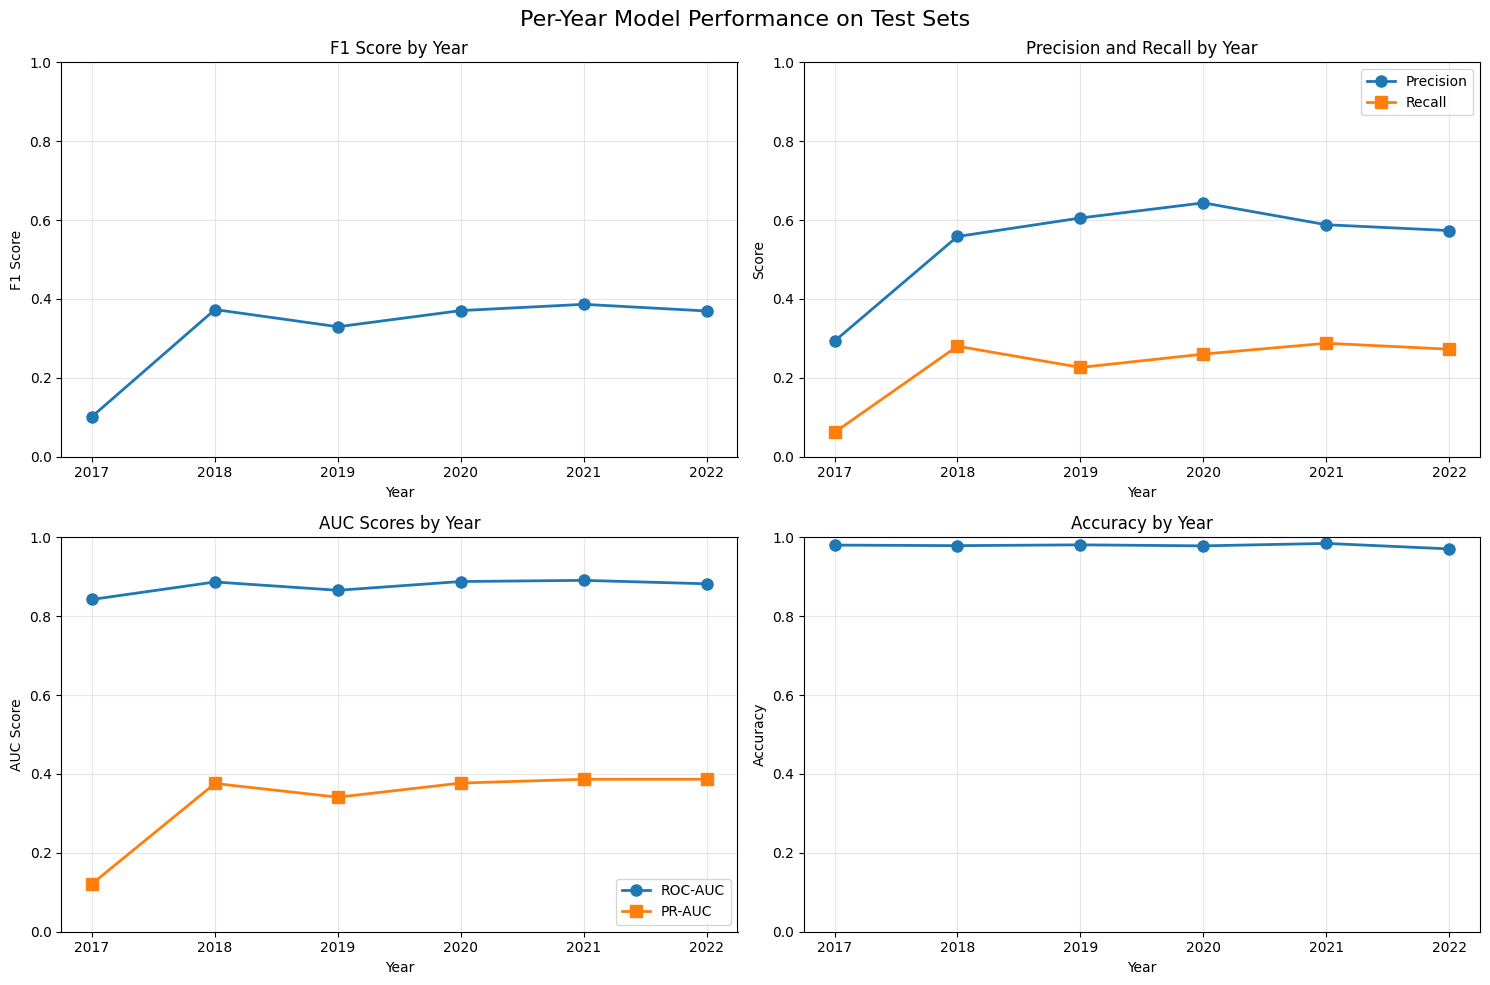

In [14]:
# Evaluate each year's model on the test set for that year

print('='*80)

print('PER-YEAR MODEL EVALUATION ON TEST SETS')

print('='*80)



decision_threshold = float(globals().get('best_threshold', 0.5))

print(f'Using decision threshold: {decision_threshold:.4f}\n')



yearly_results = []



for year_idx in range(1, n_years):

    year_val = year_values[year_idx]

    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))



    # Load the model for this year

    if not year_model_path.exists():

        print(f'\nYear {year_val}: Model file not found, skipping...')

        continue

    with open(year_model_path, 'rb') as f:

        year_model = pickle.load(f)



    # Load the scaler checkpoint for this year

    if not scaler_path.exists():

        print(f'\nYear {year_val}: Scaler file not found, skipping...')

        continue

    with open(scaler_path, 'rb') as f:

        year_scaler = pickle.load(f)



    # Get test data for this year using its scaler checkpoint

    X_test_year, y_test_year, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )



    if len(X_test_year) == 0:

        print(f'\nYear {year_val}: No test samples available, skipping...')

        continue



    # Make predictions

    y_proba_year = year_model.predict_proba(X_test_year)[:, 1]

    y_pred_year = (y_proba_year >= decision_threshold).astype(int)



    # Calculate metrics

    acc = accuracy_score(y_test_year, y_pred_year)

    prec = precision_score(y_test_year, y_pred_year, zero_division=0)

    rec = recall_score(y_test_year, y_pred_year, zero_division=0)

    f1 = f1_score(y_test_year, y_pred_year, zero_division=0)



    if len(np.unique(y_test_year)) > 1:

        roc_auc = roc_auc_score(y_test_year, y_proba_year)

        pr_auc = average_precision_score(y_test_year, y_proba_year)

    else:

        roc_auc = np.nan

        pr_auc = np.nan



    # Store results

    yearly_results.append({

        'year': year_val,

        'n_test_samples': len(X_test_year),

        'accuracy': acc,

        'precision': prec,

        'recall': rec,

        'f1_score': f1,

        'roc_auc': roc_auc,

        'pr_auc': pr_auc

    })



    # Print results

    print(f'\nYear {year_val} (Test set: {len(X_test_year)} samples):')

    print(f'  Threshold: {decision_threshold:.4f}')

    print(f'  Accuracy:  {acc:.4f}')

    print(f'  Precision: {prec:.4f}')

    print(f'  Recall:    {rec:.4f}')

    print(f'  F1 Score:  {f1:.4f}')

    print(f'  ROC-AUC:   {roc_auc:.4f}')

    print(f'  PR-AUC:    {pr_auc:.4f}')



# Create DataFrame of yearly results

yearly_results_df = pd.DataFrame(yearly_results)



print('\n' + '='*80)

print('SUMMARY TABLE - PER-YEAR TEST RESULTS')

print('='*80)

display(yearly_results_df)



# Plot per-year performance metrics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle('Per-Year Model Performance on Test Sets', fontsize=16)



# Plot 1: F1 Score

ax = axes[0, 0]

ax.plot(yearly_results_df['year'], yearly_results_df['f1_score'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Year')

ax.set_ylabel('F1 Score')

ax.set_title('F1 Score by Year')

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 2: Precision and Recall

ax = axes[0, 1]

ax.plot(yearly_results_df['year'], yearly_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)

ax.plot(yearly_results_df['year'], yearly_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)

ax.set_xlabel('Year')

ax.set_ylabel('Score')

ax.set_title('Precision and Recall by Year')

ax.legend()

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 3: AUC Scores

ax = axes[1, 0]

ax.plot(yearly_results_df['year'], yearly_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)

ax.plot(yearly_results_df['year'], yearly_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)

ax.set_xlabel('Year')

ax.set_ylabel('AUC Score')

ax.set_title('AUC Scores by Year')

ax.legend()

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 4: Accuracy

ax = axes[1, 1]

ax.plot(yearly_results_df['year'], yearly_results_df['accuracy'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Year')

ax.set_ylabel('Accuracy')

ax.set_title('Accuracy by Year')

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



plt.tight_layout()

plt.show()


## 10. Positive Rate Analysis by Split and Year

POSITIVE RATE ANALYSIS BY SPLIT AND YEAR


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 727 samples with invalid labels (class 255) for year 1
  Dropped 8827 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 1324 samples with NaN values (0.1%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 682 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6

Year 2022:
  Train: 3.06% (171390/5592362 samples)
  Val:   2.88% (36686/1272654 samples)
  Test:  3.15% (40435/1282491 samples)

SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR


,year,train_positive_rate,val_positive_rate,test_positive_rate
0,2017,0.018441,0.018801,0.018093
1,2018,0.020536,0.022132,0.022415
2,2019,0.020251,0.018276,0.020633
3,2020,0.018623,0.016915,0.024493
4,2021,0.015219,0.015570,0.016889
5,2022,0.030647,0.028826,0.031528


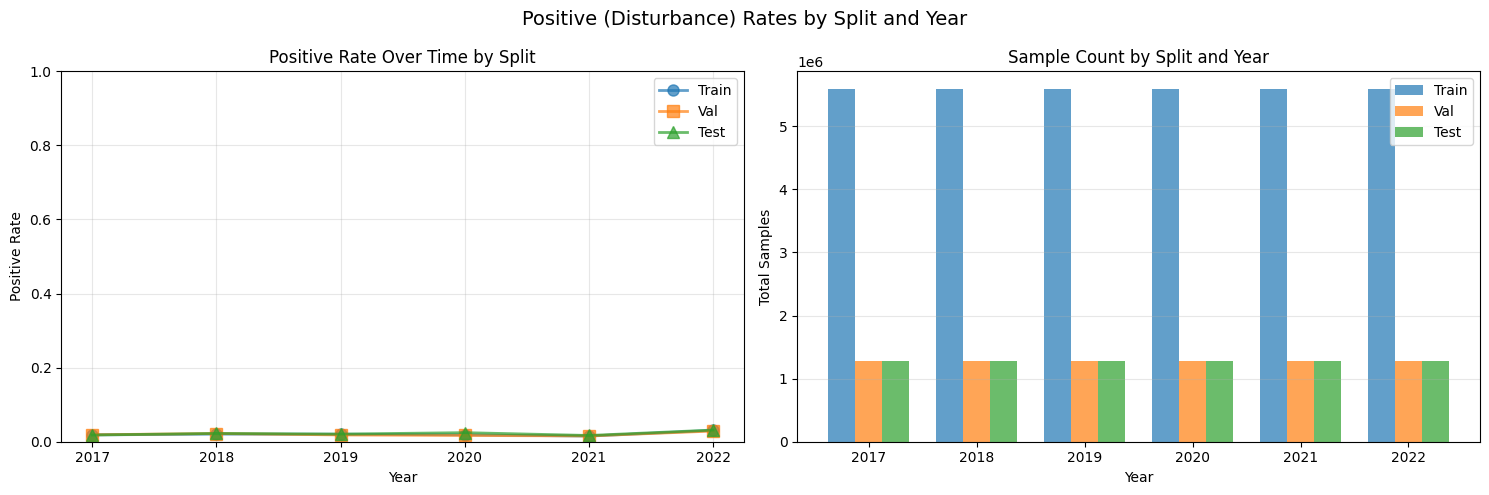


STATISTICS - POSITIVE RATES

Train Positive Rate:
count    6.000000
mean     0.020619
std      0.005265
min      0.015219
25%      0.018486
50%      0.019437
75%      0.020465
max      0.030647
Name: train_positive_rate, dtype: float64

Val Positive Rate:
count    6.000000
mean     0.020087
std      0.004816
min      0.015570
25%      0.017255
50%      0.018539
75%      0.021299
max      0.028826
Name: val_positive_rate, dtype: float64

Test Positive Rate:
count    6.000000
mean     0.022342
std      0.005287
min      0.016889
25%      0.018728
50%      0.021524
75%      0.023974
max      0.031528
Name: test_positive_rate, dtype: float64


In [15]:
# Calculate positive (disturbance) rates for each split by year

print('='*80)

print('POSITIVE RATE ANALYSIS BY SPLIT AND YEAR')

print('='*80)



split_positive_rates = []



for year_idx in range(1, n_years):

    year_val = year_values[year_idx]



    # Load year-specific scaler checkpoint (not strictly needed for labels, but keeps preprocessing consistent)

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():

        with open(scaler_path, 'rb') as f:

            year_scaler = pickle.load(f)

    else:

        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)



    if year_scaler is None:

        print(f'\nYear {year_val}: scaler checkpoint missing, skipping...')

        continue



    # Get labels for each split using the year scaler checkpoint

    X_train_year, y_train_year, _ = prepare_features_for_year(

        ds,

        train_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )

    X_val_year, y_val_year, _ = prepare_features_for_year(

        ds,

        val_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )

    X_test_year, y_test_year, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )



    # Skip if no data

    if len(y_train_year) == 0 or len(y_val_year) == 0 or len(y_test_year) == 0:

        print(f'\nYear {year_val}: Skipped (missing data in one or more splits)')

        continue



    # Calculate positive rates

    train_pos_rate = (y_train_year == 1).sum() / len(y_train_year)

    val_pos_rate = (y_val_year == 1).sum() / len(y_val_year)

    test_pos_rate = (y_test_year == 1).sum() / len(y_test_year)



    # Store results

    split_positive_rates.append({

        'year': year_val,

        'train_positive_rate': train_pos_rate,

        'train_total_samples': len(y_train_year),

        'train_positive_count': (y_train_year == 1).sum(),

        'val_positive_rate': val_pos_rate,

        'val_total_samples': len(y_val_year),

        'val_positive_count': (y_val_year == 1).sum(),

        'test_positive_rate': test_pos_rate,

        'test_total_samples': len(y_test_year),

        'test_positive_count': (y_test_year == 1).sum()

    })



    # Print results

    print(f'\nYear {year_val}:')

    print(f'  Train: {train_pos_rate:.2%} ({(y_train_year == 1).sum()}/{len(y_train_year)} samples)')

    print(f'  Val:   {val_pos_rate:.2%} ({(y_val_year == 1).sum()}/{len(y_val_year)} samples)')

    print(f'  Test:  {test_pos_rate:.2%} ({(y_test_year == 1).sum()}/{len(y_test_year)} samples)')



# Create DataFrame of positive rates

positive_rates_df = pd.DataFrame(split_positive_rates)



print('\n' + '='*80)

print('SUMMARY TABLE - POSITIVE RATES BY SPLIT AND YEAR')

print('='*80)

display(positive_rates_df[['year', 'train_positive_rate', 'val_positive_rate', 'test_positive_rate']])



# Plot positive rates by split

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle('Positive (Disturbance) Rates by Split and Year', fontsize=14)



# Plot 1: Positive rates by year

ax = axes[0]

ax.plot(positive_rates_df['year'], positive_rates_df['train_positive_rate'], 

        label='Train', marker='o', linewidth=2, markersize=8, alpha=0.7)

ax.plot(positive_rates_df['year'], positive_rates_df['val_positive_rate'], 

        label='Val', marker='s', linewidth=2, markersize=8, alpha=0.7)

ax.plot(positive_rates_df['year'], positive_rates_df['test_positive_rate'], 

        label='Test', marker='^', linewidth=2, markersize=8, alpha=0.7)

ax.set_xlabel('Year')

ax.set_ylabel('Positive Rate')

ax.set_title('Positive Rate Over Time by Split')

ax.legend()

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 2: Sample counts by split

ax = axes[1]

x_pos = np.arange(len(positive_rates_df))

width = 0.25

ax.bar(x_pos - width, positive_rates_df['train_total_samples'], width, label='Train', alpha=0.7)

ax.bar(x_pos, positive_rates_df['val_total_samples'], width, label='Val', alpha=0.7)

ax.bar(x_pos + width, positive_rates_df['test_total_samples'], width, label='Test', alpha=0.7)

ax.set_xlabel('Year')

ax.set_ylabel('Total Samples')

ax.set_title('Sample Count by Split and Year')

ax.set_xticks(x_pos)

ax.set_xticklabels([int(y) for y in positive_rates_df['year']])

ax.legend()

ax.grid(True, alpha=0.3, axis='y')



plt.tight_layout()

plt.show()



# Summary statistics

print('\n' + '='*80)

print('STATISTICS - POSITIVE RATES')

print('='*80)

print('\nTrain Positive Rate:')

print(positive_rates_df['train_positive_rate'].describe())

print('\nVal Positive Rate:')

print(positive_rates_df['val_positive_rate'].describe())

print('\nTest Positive Rate:')

print(positive_rates_df['test_positive_rate'].describe())


## 11.Final Model evaluation on each year's test set

In [16]:
# Evaluate the final trained model on each year's test set (summary table)

print('='*80)

print('FINAL MODEL EVALUATION ON EACH YEAR\'S TEST SET')

print('='*80)



decision_threshold = float(globals().get('best_threshold', 0.5))

print(f'Using decision threshold: {decision_threshold:.4f}\n')



final_model_results = []



for year_idx in range(1, n_years):

    year_val = year_values[year_idx]

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))

    if scaler_path.exists():

        with open(scaler_path, 'rb') as f:

            year_scaler = pickle.load(f)

    else:

        year_scaler = globals().get('year_to_scaler_checkpoint', {}).get(year_val)

    if year_scaler is None:

        print(f'Year {year_val}: Scaler not found, skipping...')

        continue



    X_test_year, y_test_year, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        year_idx,

        scaler=year_scaler,

        scaler_mode='transform'

    )

    if len(X_test_year) == 0:

        continue



    y_proba = model.predict_proba(X_test_year)[:, 1]

    y_pred = (y_proba >= decision_threshold).astype(int)



    acc = accuracy_score(y_test_year, y_pred)

    prec = precision_score(y_test_year, y_pred, zero_division=0)

    rec = recall_score(y_test_year, y_pred, zero_division=0)

    f1 = f1_score(y_test_year, y_pred, zero_division=0)



    if len(np.unique(y_test_year)) > 1:

        roc_auc = roc_auc_score(y_test_year, y_proba)

        pr_auc = average_precision_score(y_test_year, y_proba)

    else:

        roc_auc = np.nan

        pr_auc = np.nan



    final_model_results.append({

        'year': year_val,

        'n_test_samples': len(X_test_year),

        'accuracy': acc,

        'precision': prec,

        'recall': rec,

        'f1_score': f1,

        'roc_auc': roc_auc,

        'pr_auc': pr_auc

    })



final_model_results_df = pd.DataFrame(final_model_results)



print('\n' + '='*80)

print('SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS')

print('='*80)

display(final_model_results_df)


FINAL MODEL EVALUATION ON EACH YEAR'S TEST SET
Using decision threshold: 0.9617



C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2031 samples with NaN values (0.2%) for year 2


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2098 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6

SUMMARY TABLE - FINAL MODEL ON PER-YEAR TEST SETS


,year,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281614,0.977456,0.163501,0.059772,0.087541,0.823735,0.085010
1,2018,1281670,0.974721,0.412934,0.302934,0.349483,0.871347,0.322190
2,2019,1281599,0.959510,0.245046,0.462504,0.320358,0.862023,0.333809
3,2020,1281825,0.973673,0.451940,0.352083,0.395811,0.880157,0.362305
4,2021,1281603,0.982876,0.489360,0.319797,0.386812,0.888083,0.366562
5,2022,1282491,0.970673,0.573465,0.272586,0.369525,0.882246,0.386627


## 12. Cumulative Test Set Evaluation

CUMULATIVE TEST SET EVALUATION
Using decision threshold: 0.9617



C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1

Year 2017 model on cumulative test set (2017-2017):
  Test samples: 1,281,614
  Threshold: 0.9617
  Accuracy:  0.9803
  Precision: 0.2930
  Recall:    0.0616
  F1 Score:  0.1018
  ROC-AUC:   0.8425
  PR-AUC:    0.1215


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2098 samples with NaN values (0.2%) for year 5


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6

Year 2022 model on cumulative test set (2017-2022):
  Test samples: 7,690,802
  Threshold: 0.9617
  Accuracy:  0.9791
  Precision: 0.6043
  Recall:    0.1812
  F1 Score:  0.2788
  ROC-AUC:   0.7442
  PR-AUC:    0.2760

SUMMARY TABLE - CUMULATIVE TEST SET RESULTS


,year,n_test_samples,years_included,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281614,2017-2017,0.980333,0.293043,0.061584,0.101778,0.842550,0.121508
1,2018,2563284,2017-2018,0.980375,0.555671,0.155055,0.242455,0.710719,0.219721
2,2019,3844883,2017-2019,0.980787,0.661602,0.117241,0.199185,0.709679,0.209383
3,2020,5126708,2017-2020,0.980159,0.670674,0.143837,0.236873,0.723984,0.240511
4,2021,6408311,2017-2021,0.980803,0.614912,0.170592,0.267088,0.715325,0.251137
5,2022,7690802,2017-2022,0.979054,0.604281,0.181190,0.278788,0.744249,0.276014


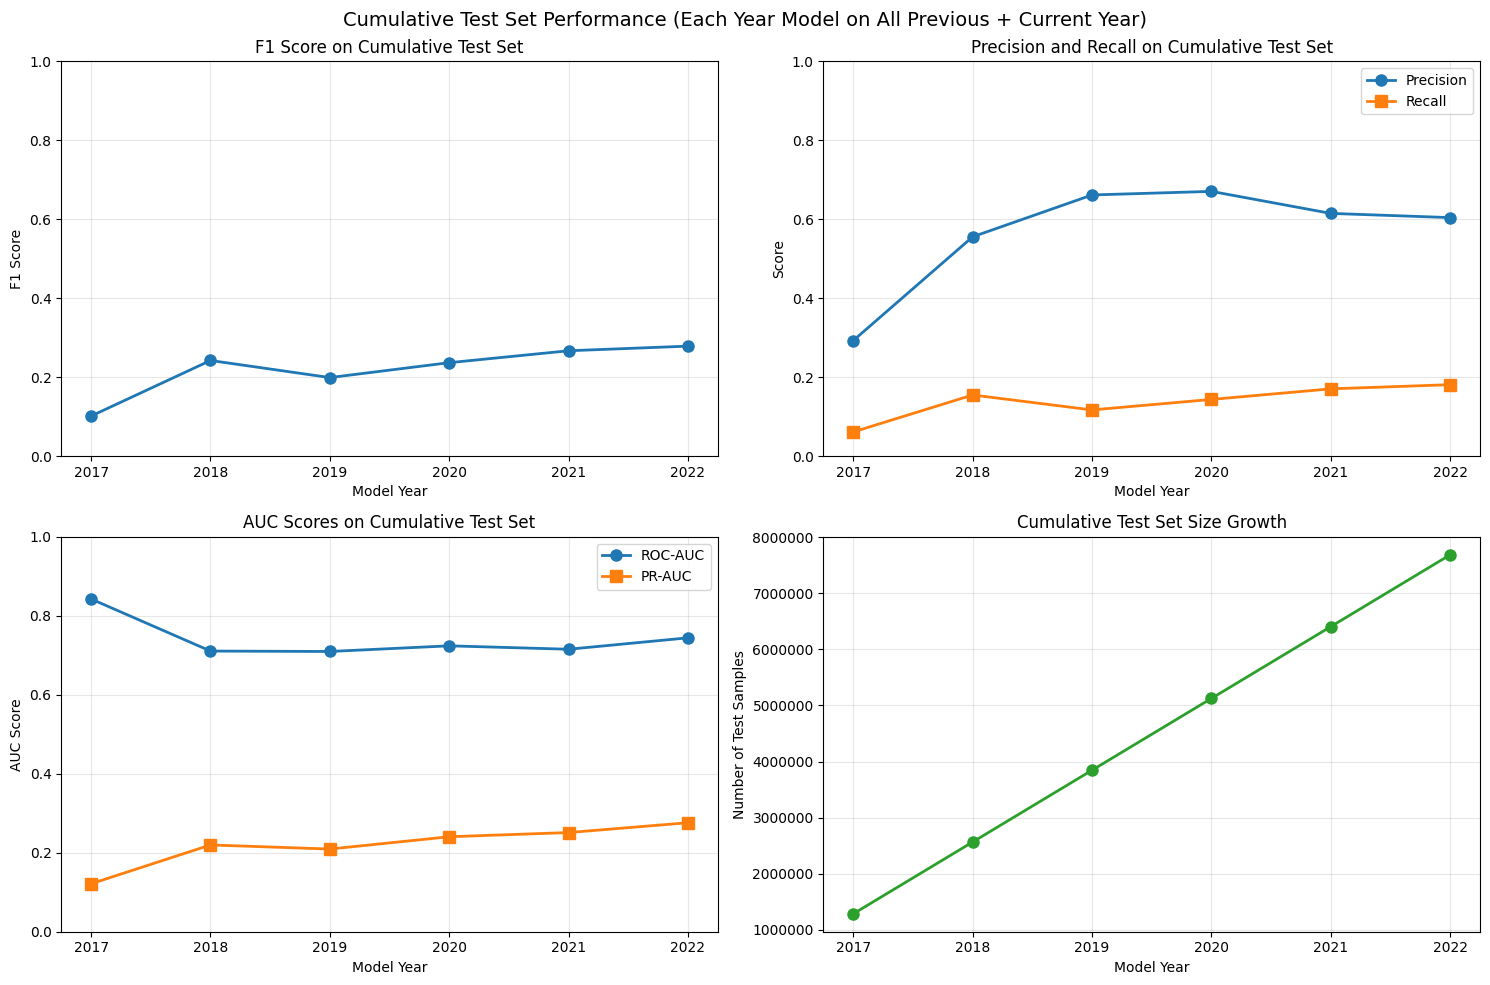

In [17]:
# Evaluate each year's model on cumulative test sets (that year + all previous years)

print('='*80)

print('CUMULATIVE TEST SET EVALUATION')

print('='*80)



decision_threshold = float(globals().get('best_threshold', 0.5))

print(f'Using decision threshold: {decision_threshold:.4f}\n')



cumulative_results = []



for year_idx in range(1, n_years):

    year_val = year_values[year_idx]

    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))



    # Load the model for this year

    if not year_model_path.exists():

        print(f'\nYear {year_val}: Model file not found, skipping...')

        continue

    with open(year_model_path, 'rb') as f:

        year_model = pickle.load(f)



    # Load the scaler checkpoint for this year

    if not scaler_path.exists():

        print(f'\nYear {year_val}: Scaler file not found, skipping...')

        continue

    with open(scaler_path, 'rb') as f:

        year_scaler = pickle.load(f)



    # Accumulate test data from year 1 up to current year,

    # scaled using the current model year's scaler checkpoint

    X_cumulative = []

    y_cumulative = []



    for past_year_idx in range(1, year_idx + 1):

        X_test_year, y_test_year, _ = prepare_features_for_year(

            ds,

            test_pixel_indices,

            past_year_idx,

            scaler=year_scaler,

            scaler_mode='transform'

        )

        if len(X_test_year) > 0:

            X_cumulative.append(X_test_year)

            y_cumulative.append(y_test_year)



    # Skip if no cumulative data

    if len(X_cumulative) == 0:

        print(f'\nYear {year_val}: No cumulative test data available, skipping...')

        continue



    # Combine all accumulated test data

    X_test_cumulative = np.vstack(X_cumulative)

    y_test_cumulative = np.concatenate(y_cumulative)



    # Make predictions

    y_proba_cumulative = year_model.predict_proba(X_test_cumulative)[:, 1]

    y_pred_cumulative = (y_proba_cumulative >= decision_threshold).astype(int)



    # Calculate metrics

    acc = accuracy_score(y_test_cumulative, y_pred_cumulative)

    prec = precision_score(y_test_cumulative, y_pred_cumulative, zero_division=0)

    rec = recall_score(y_test_cumulative, y_pred_cumulative, zero_division=0)

    f1 = f1_score(y_test_cumulative, y_pred_cumulative, zero_division=0)



    if len(np.unique(y_test_cumulative)) > 1:

        roc_auc = roc_auc_score(y_test_cumulative, y_proba_cumulative)

        pr_auc = average_precision_score(y_test_cumulative, y_proba_cumulative)

    else:

        roc_auc = np.nan

        pr_auc = np.nan



    # Store results

    cumulative_results.append({

        'year': year_val,

        'n_test_samples': len(X_test_cumulative),

        'years_included': f'2017-{int(year_val)}',

        'accuracy': acc,

        'precision': prec,

        'recall': rec,

        'f1_score': f1,

        'roc_auc': roc_auc,

        'pr_auc': pr_auc

    })



    # Print results

    print(f'\nYear {year_val} model on cumulative test set (2017-{int(year_val)}):')

    print(f'  Test samples: {len(X_test_cumulative):,}')

    print(f'  Threshold: {decision_threshold:.4f}')

    print(f'  Accuracy:  {acc:.4f}')

    print(f'  Precision: {prec:.4f}')

    print(f'  Recall:    {rec:.4f}')

    print(f'  F1 Score:  {f1:.4f}')

    print(f'  ROC-AUC:   {roc_auc:.4f}')

    print(f'  PR-AUC:    {pr_auc:.4f}')



# Create DataFrame of cumulative results

cumulative_results_df = pd.DataFrame(cumulative_results)



print('\n' + '='*80)

print('SUMMARY TABLE - CUMULATIVE TEST SET RESULTS')

print('='*80)

display(cumulative_results_df)



# Plot cumulative performance metrics

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle('Cumulative Test Set Performance (Each Year Model on All Previous + Current Year)', fontsize=14)



# Plot 1: F1 Score

ax = axes[0, 0]

ax.plot(cumulative_results_df['year'], cumulative_results_df['f1_score'], marker='o', linewidth=2, markersize=8, color='tab:blue')

ax.set_xlabel('Model Year')

ax.set_ylabel('F1 Score')

ax.set_title('F1 Score on Cumulative Test Set')

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 2: Precision and Recall

ax = axes[0, 1]

ax.plot(cumulative_results_df['year'], cumulative_results_df['precision'], label='Precision', marker='o', linewidth=2, markersize=8)

ax.plot(cumulative_results_df['year'], cumulative_results_df['recall'], label='Recall', marker='s', linewidth=2, markersize=8)

ax.set_xlabel('Model Year')

ax.set_ylabel('Score')

ax.set_title('Precision and Recall on Cumulative Test Set')

ax.legend()

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 3: AUC Scores

ax = axes[1, 0]

ax.plot(cumulative_results_df['year'], cumulative_results_df['roc_auc'], label='ROC-AUC', marker='o', linewidth=2, markersize=8)

ax.plot(cumulative_results_df['year'], cumulative_results_df['pr_auc'], label='PR-AUC', marker='s', linewidth=2, markersize=8)

ax.set_xlabel('Model Year')

ax.set_ylabel('AUC Score')

ax.set_title('AUC Scores on Cumulative Test Set')

ax.legend()

ax.grid(True, alpha=0.3)

ax.set_ylim([0, 1])



# Plot 4: Sample size growth

ax = axes[1, 1]

ax.plot(cumulative_results_df['year'], cumulative_results_df['n_test_samples'], marker='o', linewidth=2, markersize=8, color='tab:green')

ax.set_xlabel('Model Year')

ax.set_ylabel('Number of Test Samples')

ax.set_title('Cumulative Test Set Size Growth')

ax.grid(True, alpha=0.3)

ax.ticklabel_format(style='plain', axis='y')



plt.tight_layout()

plt.show()


## 13. Next-Year Model Evaluation
Evaluate each year model on the next year's test set (year t -> year t+1)

In [18]:
# Evaluate each year's model on the next year's test set (year t -> year t+1)

print('='*80)

print('NEXT-YEAR MODEL EVALUATION (Year t model on Year t+1 test set)')

print('='*80)



decision_threshold = float(globals().get('best_threshold', 0.5))

print(f'Using decision threshold: {decision_threshold:.4f}\n')



next_year_results = []



for year_idx in range(1, n_years - 1):

    year_val = year_values[year_idx]

    next_year_val = year_values[year_idx + 1]

    year_model_path = models_dir / MODEL_FILE_TEMPLATE.format(year=int(year_val))

    scaler_path = models_dir / SCALER_FILE_TEMPLATE.format(year=int(year_val))



    # Load the model for this year

    if not year_model_path.exists():

        print(f'\nYear {year_val}: Model file not found, skipping...')

        continue

    with open(year_model_path, 'rb') as f:

        year_model = pickle.load(f)



    # Load the scaler checkpoint for this year (model-year scaler)

    if not scaler_path.exists():

        print(f'\nYear {year_val}: Scaler file not found, skipping...')

        continue

    with open(scaler_path, 'rb') as f:

        year_scaler = pickle.load(f)



    # Get test data for the next year using the model-year scaler

    X_test_next, y_test_next, _ = prepare_features_for_year(

        ds,

        test_pixel_indices,

        year_idx + 1,

        scaler=year_scaler,

        scaler_mode='transform'

    )



    if len(X_test_next) == 0:

        print(f'\nYear {year_val} -> {next_year_val}: No test samples available, skipping...')

        continue



    # Make predictions

    y_proba_next = year_model.predict_proba(X_test_next)[:, 1]

    y_pred_next = (y_proba_next >= decision_threshold).astype(int)



    # Calculate metrics

    acc = accuracy_score(y_test_next, y_pred_next)

    prec = precision_score(y_test_next, y_pred_next, zero_division=0)

    rec = recall_score(y_test_next, y_pred_next, zero_division=0)

    f1 = f1_score(y_test_next, y_pred_next, zero_division=0)



    if len(np.unique(y_test_next)) > 1:

        roc_auc = roc_auc_score(y_test_next, y_proba_next)

        pr_auc = average_precision_score(y_test_next, y_proba_next)

    else:

        roc_auc = np.nan

        pr_auc = np.nan



    # Store results (year refers to model year)

    next_year_results.append({

        'year': year_val,

        'n_test_samples': len(X_test_next),

        'accuracy': acc,

        'precision': prec,

        'recall': rec,

        'f1_score': f1,

        'roc_auc': roc_auc,

        'pr_auc': pr_auc

    })



    # Print results

    print(f'\nModel year {year_val} -> Test year {next_year_val} (Test set: {len(X_test_next)} samples):')

    print(f'  Threshold: {decision_threshold:.4f}')

    print(f'  Accuracy:  {acc:.4f}')

    print(f'  Precision: {prec:.4f}')

    print(f'  Recall:    {rec:.4f}')

    print(f'  F1 Score:  {f1:.4f}')

    print(f'  ROC-AUC:   {roc_auc:.4f}')

    print(f'  PR-AUC:    {pr_auc:.4f}')



# Create DataFrame of next-year results

next_year_results_df = pd.DataFrame(next_year_results)



print('\n' + '='*80)

print('SUMMARY TABLE - NEXT-YEAR TEST RESULTS')

print('='*80)

display(next_year_results_df)


NEXT-YEAR MODEL EVALUATION (Year t model on Year t+1 test set)
Using decision threshold: 0.9617



C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 2
  Dropped 2031 samples with NaN values (0.2%) for year 2

Model year 2017 -> Test year 2018 (Test set: 1281670 samples):
  Threshold: 0.9617
  Accuracy:  0.9778
  Precision: 0.5249
  Recall:    0.0879
  F1 Score:  0.1506
  ROC-AUC:   0.8540
  PR-AUC:    0.1983


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 3
  Dropped 2102 samples with NaN values (0.2%) for year 3

Model year 2018 -> Test year 2019 (Test set: 1281599 samples):
  Threshold: 0.9617
  Accuracy:  0.9797
  Precision: 0.6452
  Recall:    0.0367
  F1 Score:  0.0695
  ROC-AUC:   0.8303
  PR-AUC:    0.1913


...

C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 5
  Dropped 2098 samples with NaN values (0.2%) for year 5

Model year 2020 -> Test year 2021 (Test set: 1281603 samples):
  Threshold: 0.9617
  Accuracy:  0.9834
  Precision: 0.5162
  Recall:    0.2575
  F1 Score:  0.3436
  ROC-AUC:   0.8820
  PR-AUC:    0.3410


C:\Users\bartu\AppData\Local\Temp\ipykernel_35100\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6

Model year 2021 -> Test year 2022 (Test set: 1282491 samples):
  Threshold: 0.9617
  Accuracy:  0.9693
  Precision: 0.5243
  Recall:    0.2837
  F1 Score:  0.3682
  ROC-AUC:   0.8775
  PR-AUC:    0.3797

SUMMARY TABLE - NEXT-YEAR TEST RESULTS


,year,n_test_samples,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2017,1281670,0.977772,0.524938,0.087925,0.150622,0.854033,0.198318
1,2018,1281599,0.979708,0.645183,0.036720,0.069486,0.830266,0.191314
2,2019,1281825,0.977862,0.610838,0.264970,0.369610,0.876192,0.368366
3,2020,1281603,0.983383,0.516162,0.257473,0.343567,0.881984,0.340993
4,2021,1282491,0.969301,0.524314,0.283715,0.368194,0.877488,0.379749


## 14. Standalone Prior-Years Evaluation by Model
Evaluate each model year on all previous years including its own year, computed locally in this section only.

In [5]:
# Standalone evaluation: each model year on all prior years (including current year)
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
 )

# Required objects from early notebook setup (data load + feature function)
required_globals = {
    "ds": "Run Section 1 (Load Prepared Data and Split) first.",
    "test_pixel_indices": "Run Section 1 (Load Prepared Data and Split) first.",
    "prepare_features_for_year": "Run Section 2 (Feature Engineering) first.",
}
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    missing_help = "\n".join([f"- {name}: {required_globals[name]}" for name in missing_globals])
    raise RuntimeError(
        "Missing required notebook objects for standalone prior-years evaluation:\n"
        f"{missing_help}"
    )

# Keep directory and naming conventions aligned with incremental-scaler notebook settings
output_suffix_local = globals().get("OUTPUT_SUFFIX", "incremental_scaler")
default_models_dir = Path(".") / f"models_lagged_features_{output_suffix_local}"
models_dir_local = Path(globals().get("models_dir", default_models_dir))

model_file_template_local = globals().get(
    "MODEL_FILE_TEMPLATE",
    f"model_year_{{year}}_lagged_features_{output_suffix_local}.pkl",
)
scaler_file_template_local = globals().get(
    "SCALER_FILE_TEMPLATE",
    f"scaler_year_{{year}}_lagged_features_{output_suffix_local}.pkl",
)

if not models_dir_local.exists():
    raise FileNotFoundError(
        f"Model directory not found: {models_dir_local.resolve()}\n"
        "Train and save yearly models/scalers before running this section."
    )

n_years_local = len(ds.year)
year_values_local = ds.year.values
result_columns = [
    "model_year",
    "year",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "n_test_samples",
    "scaler_year_used",
    "threshold_used",
    "threshold_source",
    "threshold_reason",
    "n_val_threshold_samples",
]

print(f"Using models directory: {models_dir_local.resolve()}")
print(f"Model filename template: {model_file_template_local}")
print(f"Scaler filename template: {scaler_file_template_local}")

# Global fallback threshold used only when an eval-year threshold cannot be computed
global_fallback_threshold = float(globals().get("best_threshold", 0.5))
if "best_threshold" in globals():
    print(f"Global fallback threshold (best_threshold): {global_fallback_threshold:.4f}")
else:
    print(f"No best_threshold found. Using default fallback threshold: {global_fallback_threshold:.4f}")

has_val_indices = "val_pixel_indices" in globals()
if not has_val_indices:
    print(
        "Warning: val_pixel_indices not found. Eval-year threshold tuning is disabled; "
        "fallback threshold will be used."
    )

# Stores only tables computed by this section
standalone_prior_year_tables = {}
standalone_prior_year_rows_all = []

# Backward-compatible outputs used by later sections
model_year_thresholds = {}
model_year_threshold_meta = {}

# New detailed threshold outputs (model year -> eval year -> threshold/meta)
model_eval_year_thresholds = {}
model_eval_year_threshold_meta = {}

# Cache scalers to avoid repeated disk reads within this section
scaler_cache = {}


def load_scaler_for_year(year_val):
    """Load scaler for a specific calendar year with optional in-memory fallback."""
    year_key = int(year_val)
    if year_key in scaler_cache:
        return scaler_cache[year_key]

    scaler_path_year = models_dir_local / scaler_file_template_local.format(year=year_key)
    scaler_obj = None

    if scaler_path_year.exists():
        with open(scaler_path_year, "rb") as f:
            scaler_obj = pickle.load(f)
    else:
        # Fallback for in-session training where files may not be persisted yet.
        in_memory_scalers = globals().get("year_to_scaler_checkpoint", {})
        if not in_memory_scalers:
            in_memory_scalers = globals().get("year_to_scaler", {})

        if year_key in in_memory_scalers:
            scaler_obj = in_memory_scalers[year_key]
        elif year_val in in_memory_scalers:
            scaler_obj = in_memory_scalers[year_val]

    if scaler_obj is not None:
        scaler_cache[year_key] = scaler_obj

    return scaler_obj


def compute_eval_year_threshold(year_model, eval_year_idx, eval_year_scaler):
    """Tune threshold for one model-year/eval-year pair on eval-year validation data."""
    threshold_local = global_fallback_threshold
    threshold_source = "fallback_global"
    threshold_reason = "best_threshold/default"
    n_val_threshold_samples = 0

    if not has_val_indices:
        return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples

    X_val_year, y_val_year, _ = prepare_features_for_year(
        ds,
        val_pixel_indices,
        eval_year_idx,
        scaler=eval_year_scaler,
        scaler_mode='transform',
    )

    if len(X_val_year) == 0:
        threshold_reason = "no validation samples after preprocessing"
        return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples

    n_val_threshold_samples = int(len(y_val_year))
    y_val_proba = year_model.predict_proba(X_val_year)[:, 1]

    if len(np.unique(y_val_year)) > 1:
        precision_vals, recall_vals, thresholds = precision_recall_curve(y_val_year, y_val_proba)
        f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)
        best_idx = int(np.argmax(f1_vals))

        if best_idx < len(thresholds):
            threshold_local = float(thresholds[best_idx])
            threshold_source = "computed_pr_f1_eval_year"
            threshold_reason = (
                f"max F1 on eval-year {int(year_values_local[eval_year_idx])} validation PR curve"
            )
        else:
            threshold_reason = "PR argmax at terminal point without explicit threshold"
    else:
        threshold_reason = "validation labels contain one class only"

    return threshold_local, threshold_source, threshold_reason, n_val_threshold_samples


print("=" * 80)
print("STANDALONE PRIOR-YEARS EVALUATION BY MODEL YEAR")
print("=" * 80)

for model_year_idx in range(1, n_years_local):
    model_year_val = year_values_local[model_year_idx]
    model_year_key = int(model_year_val)
    model_path = models_dir_local / model_file_template_local.format(year=model_year_key)

    if not model_path.exists():
        print(f"\nModel year {model_year_key}: model file not found, skipping.")
        continue

    with open(model_path, "rb") as f:
        year_model = pickle.load(f)

    model_eval_year_thresholds[model_year_key] = {}
    model_eval_year_threshold_meta[model_year_key] = {}
    model_year_rows = []

    print(
        f"\nModel year {model_year_key}: evaluating years <= {model_year_key} "
        "using each eval year's scaler."
    )

    for eval_year_idx in range(1, model_year_idx + 1):
        eval_year_val = year_values_local[eval_year_idx]
        eval_year_key = int(eval_year_val)

        # Core policy: use the evaluated year's scaler.
        eval_year_scaler = load_scaler_for_year(eval_year_val)
        if eval_year_scaler is None:
            print(
                f"  Model {model_year_key} -> Eval {eval_year_key}: "
                "eval-year scaler not found, skipped."
            )
            continue

        (
            threshold_local,
            threshold_source,
            threshold_reason,
            n_val_threshold_samples,
        ) = compute_eval_year_threshold(year_model, eval_year_idx, eval_year_scaler)

        model_eval_year_thresholds[model_year_key][eval_year_key] = threshold_local
        model_eval_year_threshold_meta[model_year_key][eval_year_key] = {
            "source": threshold_source,
            "reason": threshold_reason,
            "n_val_samples": int(n_val_threshold_samples),
        }

        X_eval, y_eval, _ = prepare_features_for_year(
            ds,
            test_pixel_indices,
            eval_year_idx,
            scaler=eval_year_scaler,
            scaler_mode='transform',
        )

        if len(X_eval) == 0:
            print(
                f"  Model {model_year_key} -> Eval {eval_year_key}: "
                "no samples after preprocessing, skipped."
            )
            continue

        y_proba = year_model.predict_proba(X_eval)[:, 1]
        y_pred = (y_proba >= threshold_local).astype(int)

        acc = accuracy_score(y_eval, y_pred)
        prec = precision_score(y_eval, y_pred, zero_division=0)
        rec = recall_score(y_eval, y_pred, zero_division=0)
        f1 = f1_score(y_eval, y_pred, zero_division=0)

        if len(np.unique(y_eval)) > 1:
            roc_auc = roc_auc_score(y_eval, y_proba)
            pr_auc = average_precision_score(y_eval, y_proba)
        else:
            roc_auc = np.nan
            pr_auc = np.nan

        result_row = {
            "model_year": model_year_key,
            "year": eval_year_val,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "roc_auc": roc_auc,
            "pr_auc": pr_auc,
            "n_test_samples": len(X_eval),
            "scaler_year_used": eval_year_key,
            "threshold_used": threshold_local,
            "threshold_source": threshold_source,
            "threshold_reason": threshold_reason,
            "n_val_threshold_samples": int(n_val_threshold_samples),
        }
        model_year_rows.append(result_row)
        standalone_prior_year_rows_all.append(result_row)

        print(
            f"  Model {model_year_key} -> Eval {eval_year_key}: "
            f"threshold={threshold_local:.4f} ({threshold_source}), F1={f1:.4f}"
        )

    if not model_year_rows:
        print(f"\nModel year {model_year_key}: no evaluable prior-year data, table not created.")
        continue

    # Backward compatibility for downstream diagnostics: keep one threshold per model year
    own_year_threshold = model_eval_year_thresholds[model_year_key].get(model_year_key)
    own_year_meta = model_eval_year_threshold_meta[model_year_key].get(model_year_key)

    if own_year_threshold is not None and own_year_meta is not None:
        model_year_thresholds[model_year_key] = own_year_threshold
        model_year_threshold_meta[model_year_key] = own_year_meta.copy()
    else:
        model_year_thresholds[model_year_key] = global_fallback_threshold
        model_year_threshold_meta[model_year_key] = {
            "source": "fallback_global",
            "reason": "own-year threshold unavailable",
            "n_val_samples": 0,
        }

    model_year_df = pd.DataFrame(model_year_rows)
    ordered_columns = [col for col in result_columns if col in model_year_df.columns]
    model_year_df = model_year_df[ordered_columns].copy()
    standalone_prior_year_tables[model_year_key] = model_year_df

    print("\n" + "=" * 80)
    print(f"MODEL YEAR {model_year_key} -> EVALUATED ON YEARS <= {model_year_key}")
    print("=" * 80)
    display(model_year_df)

standalone_prior_year_all_df = pd.DataFrame(standalone_prior_year_rows_all)
if not standalone_prior_year_all_df.empty:
    standalone_prior_year_all_df = standalone_prior_year_all_df[result_columns].copy()

if not standalone_prior_year_tables:
    print("\nNo standalone prior-years tables were produced.")
else:
    print(f"\nGenerated {len(standalone_prior_year_tables)} standalone prior-years tables.")
    print("Per-model/eval-year thresholds are available in model_eval_year_thresholds.")
    print("Backward-compatible per-model thresholds are available in model_year_thresholds.")

Using models directory: C:\Users\bartu\Desktop\Fonda-scikit\models_lagged_features_incremental_scaler
Model filename template: model_year_{year}_lagged_features_incremental_scaler.pkl
Scaler filename template: scaler_year_{year}_lagged_features_incremental_scaler.pkl
No best_threshold found. Using default fallback threshold: 0.5000
STANDALONE PRIOR-YEARS EVALUATION BY MODEL YEAR

Model year 2017: evaluating years <= 2017 using each eval year's scaler.


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 1324 samples with NaN values (0.1%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1
  Model 2017 -> Eval 2017: threshold=0.8454 (computed_pr_f1_eval_year), F1=0.1996

MODEL YEAR 2017 -> EVALUATED ON YEARS <= 2017


...

  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 682 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6
  Model 2022 -> Eval 2022: threshold=0.9089 (computed_pr_f1_eval_year), F1=0.4118

MODEL YEAR 2022 -> EVALUATED ON YEARS <= 2022


,model_year,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,scaler_year_used,threshold_used,threshold_source,threshold_reason,n_val_threshold_samples
0,2022,2017,0.954188,0.117871,0.236286,0.157282,0.823735,0.085010,1281614,2017,0.762389,computed_pr_f1_eval_year,max F1 on eval-year 2017 validation PR curve,1272012
1,2022,2018,0.970797,0.346789,0.342685,0.344725,0.871347,0.322190,1281670,2018,0.950540,computed_pr_f1_eval_year,max F1 on eval-year 2018 validation PR curve,1272044
2,2022,2019,0.977335,0.437180,0.342662,0.384193,0.862023,0.333809,1281599,2019,0.981950,computed_pr_f1_eval_year,max F1 on eval-year 2019 validation PR curve,1271918
3,2022,2020,0.973500,0.448112,0.353739,0.395372,0.880157,0.362305,1281825,2020,0.961151,computed_pr_f1_eval_year,max F1 on eval-year 2020 validation PR curve,1271971
4,2022,2021,0.982754,0.484113,0.322384,0.387032,0.888083,0.366562,1281603,2021,0.960835,computed_pr_f1_eval_year,max F1 on eval-year 2021 validation PR curve,1271903
5,2022,2022,0.960706,0.389919,0.436206,0.411766,0.882246,0.386627,1282491,2022,0.908929,computed_pr_f1_eval_year,max F1 on eval-year 2022 validation PR curve,1272654



Generated 6 standalone prior-years tables.
Per-model/eval-year thresholds are available in model_eval_year_thresholds.
Backward-compatible per-model thresholds are available in model_year_thresholds.


## 15. Side-by-Side Comparison of All Evaluation Approaches

In [19]:
# Compare all evaluation approaches with separate tables
print('='*80)
print('EVALUATION RESULTS: FIVE SEPARATE APPROACHES')
print('='*80)

# Table 1: Final Model on each year
print('\n' + '='*80)
print('TABLE 1: Final Model (trained on all years) evaluated on each year')
print('='*80)
table1 = final_model_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table1)

# Table 2: Year-specific Model on that year
print('\n' + '='*80)
print('TABLE 2: Year-Specific Model evaluated on that year only')
print('='*80)
table2 = yearly_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table2)

# Table 3: Year-specific Model on cumulative test set
print('\n' + '='*80)
print('TABLE 3: Year-Specific Model evaluated on cumulative test set (all years up to that year)')
print('='*80)
table3 = cumulative_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table3)

# Table 4: Year-specific Model on next year's test set
print('\n' + '='*80)
print('TABLE 4: Year-Specific Model evaluated on next year\'s test set (year t -> year t+1)')
print('='*80)
table4 = next_year_results_df[['year', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'n_test_samples']].copy()
display(table4)

# Table 5: Standalone model-year on each previous year (including own year)
print('\n' + '='*80)
print('TABLE 5: Model-Year evaluated on each previous year (including own year)')
print('='*80)
if 'standalone_prior_year_all_df' in globals() and not standalone_prior_year_all_df.empty:
    desired_cols = [
        'model_year',
        'year',
        'accuracy',
        'precision',
        'recall',
        'f1_score',
        'roc_auc',
        'pr_auc',
        'n_test_samples',
        'scaler_year_used',
        'threshold_used',
        'threshold_source',
    ]
    table5_cols = [col for col in desired_cols if col in standalone_prior_year_all_df.columns]
    table5 = standalone_prior_year_all_df[table5_cols].copy()
    display(table5)
else:
    print('Standalone prior-years evaluation table not available. Run Section 14 first.')

print(f"\nNote: All tables use a decision threshold sourced from best_threshold (fallback=0.5) for converting probabilities to class labels.")

EVALUATION RESULTS: FOUR SEPARATE APPROACHES

TABLE 1: Final Model (trained on all years) evaluated on each year


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.977456,0.163501,0.059772,0.087541,0.823735,0.085010,1281614
1,2018,0.974721,0.412934,0.302934,0.349483,0.871347,0.322190,1281670
2,2019,0.959510,0.245046,0.462504,0.320358,0.862023,0.333809,1281599
3,2020,0.973673,0.451940,0.352083,0.395811,0.880157,0.362305,1281825
4,2021,0.982876,0.489360,0.319797,0.386812,0.888083,0.366562,1281603
5,2022,0.970673,0.573465,0.272586,0.369525,0.882246,0.386627,1282491



TABLE 2: Year-Specific Model evaluated on that year only


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.980333,0.293043,0.061584,0.101778,0.842550,0.121508,1281614
1,2018,0.978899,0.558407,0.280205,0.373160,0.886804,0.375879,1281670
2,2019,0.980992,0.605298,0.226412,0.329554,0.865724,0.341089,1281599
3,2020,0.978351,0.643656,0.260161,0.370548,0.887983,0.376934,1281825
4,2021,0.984569,0.588213,0.287734,0.386436,0.890868,0.386522,1281603
5,2022,0.970673,0.573465,0.272586,0.369525,0.882246,0.386627,1282491



TABLE 3: Year-Specific Model evaluated on cumulative test set (all years up to that year)


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.980333,0.293043,0.061584,0.101778,0.842550,0.121508,1281614
1,2018,0.980375,0.555671,0.155055,0.242455,0.710719,0.219721,2563284
2,2019,0.980787,0.661602,0.117241,0.199185,0.709679,0.209383,3844883
3,2020,0.980159,0.670674,0.143837,0.236873,0.723984,0.240511,5126708
4,2021,0.980803,0.614912,0.170592,0.267088,0.715325,0.251137,6408311
5,2022,0.979054,0.604281,0.181190,0.278788,0.744249,0.276014,7690802



TABLE 4: Year-Specific Model evaluated on next year's test set (year t -> year t+1)


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples
0,2017,0.977772,0.524938,0.087925,0.150622,0.854033,0.198318,1281670
1,2018,0.979708,0.645183,0.036720,0.069486,0.830266,0.191314,1281599
2,2019,0.977862,0.610838,0.264970,0.369610,0.876192,0.368366,1281825
3,2020,0.983383,0.516162,0.257473,0.343567,0.881984,0.340993,1281603
4,2021,0.969301,0.524314,0.283715,0.368194,0.877488,0.379749,1282491



Note: All tables use the decision threshold = 0.9617 for converting probabilities to class labels.


## 16. Prior-Years Evaluation Using Model-Year Scaler (TEMP – DELETE LATER)
Same as Section 14 but each model's scaler (fitted up to model year) is used for **all** eval years, instead of each eval year's own scaler.

In [6]:
# Standalone evaluation: each model year on all prior years (including current year)
# KEY DIFFERENCE from Section 14: the model year's scaler is used for ALL eval years
#                                  (not each eval year's own scaler).
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

# Required objects from early notebook setup (data load + feature function)
required_globals_s16 = {
    "ds": "Run Section 1 (Load Prepared Data and Split) first.",
    "test_pixel_indices": "Run Section 1 (Load Prepared Data and Split) first.",
    "prepare_features_for_year": "Run Section 2 (Feature Engineering) first.",
}
missing_s16 = [n for n in required_globals_s16 if n not in globals()]
if missing_s16:
    raise RuntimeError(
        "Missing required notebook objects for Section 16:\n"
        + "\n".join([f"- {n}: {required_globals_s16[n]}" for n in missing_s16])
    )

# Use same directory and naming conventions as the rest of the notebook
output_suffix_s16 = globals().get("OUTPUT_SUFFIX", "incremental_scaler")
default_models_dir_s16 = Path(".") / f"models_lagged_features_{output_suffix_s16}"
models_dir_s16 = Path(globals().get("models_dir", default_models_dir_s16))

model_file_template_s16 = globals().get(
    "MODEL_FILE_TEMPLATE",
    f"model_year_{{year}}_lagged_features_{output_suffix_s16}.pkl",
)
scaler_file_template_s16 = globals().get(
    "SCALER_FILE_TEMPLATE",
    f"scaler_year_{{year}}_lagged_features_{output_suffix_s16}.pkl",
)

if not models_dir_s16.exists():
    raise FileNotFoundError(
        f"Model directory not found: {models_dir_s16.resolve()}\n"
        "Train and save yearly models/scalers before running this section."
    )

n_years_s16 = len(ds.year)
year_values_s16 = ds.year.values
result_columns_s16 = [
    "model_year",
    "year",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "n_test_samples",
    "scaler_year_used",
    "threshold_used",
    "threshold_source",
    "threshold_reason",
    "n_val_threshold_samples",
]

print(f"Using models directory: {models_dir_s16.resolve()}")
print(f"Model filename template: {model_file_template_s16}")
print(f"Scaler filename template: {scaler_file_template_s16}")

global_fallback_threshold_s16 = float(globals().get("best_threshold", 0.5))
print(
    f"Global fallback threshold: {global_fallback_threshold_s16:.4f} "
    f"({'best_threshold' if 'best_threshold' in globals() else 'default'})"
)

has_val_s16 = "val_pixel_indices" in globals()
if not has_val_s16:
    print(
        "Warning: val_pixel_indices not found. "
        "Eval-year threshold tuning is disabled; fallback threshold will be used."
    )

# Output variables (separate from Section 14 to avoid overwriting)
s16_prior_year_tables = {}
s16_prior_year_rows_all = []
s16_model_year_thresholds = {}
s16_model_year_threshold_meta = {}
s16_model_eval_year_thresholds = {}
s16_model_eval_year_threshold_meta = {}

# In-memory scaler cache (reset each section run)
scaler_cache_s16 = {}


def load_scaler_s16(year_val):
    """Load scaler for a given calendar year (from disk or in-memory fallback)."""
    year_key = int(year_val)
    if year_key in scaler_cache_s16:
        return scaler_cache_s16[year_key]

    scaler_path = models_dir_s16 / scaler_file_template_s16.format(year=year_key)
    scaler_obj = None

    if scaler_path.exists():
        with open(scaler_path, "rb") as f_s16:
            scaler_obj = pickle.load(f_s16)
    else:
        # Fallback to in-memory checkpoints saved during training
        in_mem = globals().get("year_to_scaler_checkpoint", globals().get("year_to_scaler", {}))
        scaler_obj = in_mem.get(year_key) or in_mem.get(year_val)

    if scaler_obj is not None:
        scaler_cache_s16[year_key] = scaler_obj
    return scaler_obj


def compute_threshold_s16(year_model, eval_year_idx, scaler_to_use):
    """Tune threshold on eval-year validation data using the given scaler."""
    threshold = global_fallback_threshold_s16
    source = "fallback_global"
    reason = "best_threshold/default"
    n_val = 0

    if not has_val_s16:
        return threshold, source, reason, n_val

    X_v, y_v, _ = prepare_features_for_year(
        ds,
        val_pixel_indices,
        eval_year_idx,
        scaler=scaler_to_use,
        scaler_mode="transform",
    )

    if len(X_v) == 0:
        reason = "no validation samples after preprocessing"
        return threshold, source, reason, n_val

    n_val = int(len(y_v))
    y_v_proba = year_model.predict_proba(X_v)[:, 1]

    if len(np.unique(y_v)) > 1:
        prec_v, rec_v, thr_v = precision_recall_curve(y_v, y_v_proba)
        f1_v = 2 * (prec_v * rec_v) / (prec_v + rec_v + 1e-12)
        best_i = int(np.argmax(f1_v))
        if best_i < len(thr_v):
            threshold = float(thr_v[best_i])
            source = "computed_pr_f1_model_year_scaler"
            reason = (
                f"max F1 on eval-year {int(year_values_s16[eval_year_idx])} "
                "val PR curve (model-year scaler)"
            )
        else:
            reason = "PR argmax at terminal point without explicit threshold"
    else:
        reason = "validation labels contain one class only"

    return threshold, source, reason, n_val


print("=" * 80)
print("PRIOR-YEARS EVALUATION BY MODEL YEAR — USING MODEL-YEAR SCALER")
print("=" * 80)

for mi in range(1, n_years_s16):
    model_year_val_s16 = year_values_s16[mi]
    model_year_key_s16 = int(model_year_val_s16)
    model_path_s16 = models_dir_s16 / model_file_template_s16.format(year=model_year_key_s16)

    if not model_path_s16.exists():
        print(f"\nModel year {model_year_key_s16}: model file not found, skipping.")
        continue

    with open(model_path_s16, "rb") as f_s16:
        year_model_s16 = pickle.load(f_s16)

    # Load the scaler for the MODEL year (reused for all eval years)
    model_scaler_s16 = load_scaler_s16(model_year_val_s16)
    if model_scaler_s16 is None:
        print(
            f"\nModel year {model_year_key_s16}: model-year scaler not found, skipping all evals."
        )
        continue

    s16_model_eval_year_thresholds[model_year_key_s16] = {}
    s16_model_eval_year_threshold_meta[model_year_key_s16] = {}
    model_year_rows_s16 = []

    print(
        f"\nModel year {model_year_key_s16}: evaluating years <= {model_year_key_s16} "
        f"using scaler from year {model_year_key_s16}."
    )

    for ei in range(1, mi + 1):
        eval_year_val_s16 = year_values_s16[ei]
        eval_year_key_s16 = int(eval_year_val_s16)

        # Use the model year's scaler for threshold tuning and feature transformation
        thr_s16, src_s16, rsn_s16, n_val_s16 = compute_threshold_s16(
            year_model_s16, ei, model_scaler_s16
        )

        s16_model_eval_year_thresholds[model_year_key_s16][eval_year_key_s16] = thr_s16
        s16_model_eval_year_threshold_meta[model_year_key_s16][eval_year_key_s16] = {
            "source": src_s16,
            "reason": rsn_s16,
            "n_val_samples": int(n_val_s16),
        }

        X_ev, y_ev, _ = prepare_features_for_year(
            ds,
            test_pixel_indices,
            ei,
            scaler=model_scaler_s16,
            scaler_mode="transform",
        )

        if len(X_ev) == 0:
            print(
                f"  Model {model_year_key_s16} -> Eval {eval_year_key_s16}: "
                "no samples after preprocessing, skipped."
            )
            continue

        y_proba_s16 = year_model_s16.predict_proba(X_ev)[:, 1]
        y_pred_s16 = (y_proba_s16 >= thr_s16).astype(int)

        acc_s16 = accuracy_score(y_ev, y_pred_s16)
        prec_s16 = precision_score(y_ev, y_pred_s16, zero_division=0)
        rec_s16 = recall_score(y_ev, y_pred_s16, zero_division=0)
        f1_s16 = f1_score(y_ev, y_pred_s16, zero_division=0)

        if len(np.unique(y_ev)) > 1:
            roc_s16 = roc_auc_score(y_ev, y_proba_s16)
            prauc_s16 = average_precision_score(y_ev, y_proba_s16)
        else:
            roc_s16 = np.nan
            prauc_s16 = np.nan

        row_s16 = {
            "model_year": model_year_key_s16,
            "year": eval_year_val_s16,
            "accuracy": acc_s16,
            "precision": prec_s16,
            "recall": rec_s16,
            "f1_score": f1_s16,
            "roc_auc": roc_s16,
            "pr_auc": prauc_s16,
            "n_test_samples": len(X_ev),
            "scaler_year_used": model_year_key_s16,  # always the model year
            "threshold_used": thr_s16,
            "threshold_source": src_s16,
            "threshold_reason": rsn_s16,
            "n_val_threshold_samples": int(n_val_s16),
        }
        model_year_rows_s16.append(row_s16)
        s16_prior_year_rows_all.append(row_s16)

        print(
            f"  Model {model_year_key_s16} -> Eval {eval_year_key_s16}: "
            f"threshold={thr_s16:.4f} ({src_s16}), F1={f1_s16:.4f}"
        )

    if not model_year_rows_s16:
        print(f"\nModel year {model_year_key_s16}: no evaluable data, table not created.")
        continue

    # Backward-compatible single threshold per model year (own year)
    own_thr_s16 = s16_model_eval_year_thresholds[model_year_key_s16].get(model_year_key_s16)
    own_meta_s16 = s16_model_eval_year_threshold_meta[model_year_key_s16].get(model_year_key_s16)
    if own_thr_s16 is not None and own_meta_s16 is not None:
        s16_model_year_thresholds[model_year_key_s16] = own_thr_s16
        s16_model_year_threshold_meta[model_year_key_s16] = own_meta_s16.copy()
    else:
        s16_model_year_thresholds[model_year_key_s16] = global_fallback_threshold_s16
        s16_model_year_threshold_meta[model_year_key_s16] = {
            "source": "fallback_global",
            "reason": "own-year threshold unavailable",
            "n_val_samples": 0,
        }

    df_s16 = pd.DataFrame(model_year_rows_s16)
    ordered_cols_s16 = [c for c in result_columns_s16 if c in df_s16.columns]
    df_s16 = df_s16[ordered_cols_s16].copy()
    s16_prior_year_tables[model_year_key_s16] = df_s16

    print("\n" + "=" * 80)
    print(f"MODEL YEAR {model_year_key_s16} -> EVALUATED ON YEARS <= {model_year_key_s16}")
    print(f"(scaler from year {model_year_key_s16} applied to all eval years)")
    print("=" * 80)
    display(df_s16)

s16_prior_year_all_df = pd.DataFrame(s16_prior_year_rows_all)
if not s16_prior_year_all_df.empty:
    s16_prior_year_all_df = s16_prior_year_all_df[result_columns_s16].copy()

if not s16_prior_year_tables:
    print("\nNo tables produced in Section 16.")
else:
    print(f"\nSection 16: Generated {len(s16_prior_year_tables)} tables.")
    print("Results stored in s16_prior_year_tables and s16_prior_year_all_df.")
    print("Per-model/eval-year thresholds stored in s16_model_eval_year_thresholds.")


Using models directory: C:\Users\bartu\Desktop\Fonda-scikit\models_lagged_features_incremental_scaler
Model filename template: model_year_{year}_lagged_features_incremental_scaler.pkl
Scaler filename template: scaler_year_{year}_lagged_features_incremental_scaler.pkl
Global fallback threshold: 0.5000 (default)
PRIOR-YEARS EVALUATION BY MODEL YEAR — USING MODEL-YEAR SCALER

Model year 2017: evaluating years <= 2017 using scaler from year 2017.


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 1324 samples with NaN values (0.1%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1
  Model 2017 -> Eval 2017: threshold=0.8454 (computed_pr_f1_model_year_scaler), F1=0.1996

MODEL YEAR 2017 -> EVALUATED ON YEARS <= 2017
(scaler from year 2017 applied to all eval years)


...

  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 682 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6
  Model 2022 -> Eval 2022: threshold=0.9089 (computed_pr_f1_model_year_scaler), F1=0.4118

MODEL YEAR 2022 -> EVALUATED ON YEARS <= 2022
(scaler from year 2022 applied to all eval years)


,model_year,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,scaler_year_used,threshold_used,threshold_source,threshold_reason,n_val_threshold_samples
0,2022,2017,0.954398,0.118359,0.235769,0.157600,0.824106,0.085307,1281614,2022,0.000316,computed_pr_f1_model_year_scaler,max F1 on eval-year 2017 val PR curve (model-y...,1272012
1,2022,2018,0.972092,0.370293,0.349786,0.359747,0.875862,0.332058,1281670,2022,0.170110,computed_pr_f1_model_year_scaler,max F1 on eval-year 2018 val PR curve (model-y...,1272044
2,2022,2019,0.977450,0.441430,0.350149,0.390527,0.860643,0.339775,1281599,2022,0.902682,computed_pr_f1_model_year_scaler,max F1 on eval-year 2019 val PR curve (model-y...,1271918
3,2022,2020,0.974038,0.461225,0.356701,0.402285,0.882320,0.368690,1281825,2022,0.910336,computed_pr_f1_model_year_scaler,max F1 on eval-year 2020 val PR curve (model-y...,1271971
4,2022,2021,0.982843,0.487896,0.320305,0.386724,0.887458,0.368186,1281603,2022,0.941413,computed_pr_f1_model_year_scaler,max F1 on eval-year 2021 val PR curve (model-y...,1271903
5,2022,2022,0.960706,0.389919,0.436206,0.411766,0.882246,0.386627,1282491,2022,0.908929,computed_pr_f1_model_year_scaler,max F1 on eval-year 2022 val PR curve (model-y...,1272654



Section 16: Generated 6 tables.
Results stored in s16_prior_year_tables and s16_prior_year_all_df.
Per-model/eval-year thresholds stored in s16_model_eval_year_thresholds.


## 17. Prior-Years Evaluation: Model-Year Scaler for Threshold and Predictions (TEMP – DELETE LATER)
Adjusted variant: both threshold tuning on validation data and test-time predictions use the **model-year scaler**.

In [9]:
# Prior-years evaluation: model-year scaler used for both threshold tuning and predictions.
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

required_globals_s17 = {
    "ds": "Run Section 1 (Load Prepared Data and Split) first.",
    "test_pixel_indices": "Run Section 1 (Load Prepared Data and Split) first.",
    "prepare_features_for_year": "Run Section 2 (Feature Engineering) first.",
}
missing_s17 = [n for n in required_globals_s17 if n not in globals()]
if missing_s17:
    raise RuntimeError(
        "Missing required notebook objects for Section 17:\n"
        + "\n".join([f"- {n}: {required_globals_s17[n]}" for n in missing_s17])
    )

output_suffix_s17 = globals().get("OUTPUT_SUFFIX", "incremental_scaler")
default_models_dir_s17 = Path(".") / f"models_lagged_features_{output_suffix_s17}"
models_dir_s17 = Path(globals().get("models_dir", default_models_dir_s17))

model_file_template_s17 = globals().get(
    "MODEL_FILE_TEMPLATE",
    f"model_year_{{year}}_lagged_features_{output_suffix_s17}.pkl",
)
scaler_file_template_s17 = globals().get(
    "SCALER_FILE_TEMPLATE",
    f"scaler_year_{{year}}_lagged_features_{output_suffix_s17}.pkl",
)

if not models_dir_s17.exists():
    raise FileNotFoundError(
        f"Model directory not found: {models_dir_s17.resolve()}\n"
        "Train and save yearly models/scalers before running this section."
    )

n_years_s17 = len(ds.year)
year_values_s17 = ds.year.values
result_columns_s17 = [
    "model_year",
    "year",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "n_test_samples",
    "threshold_scaler_year",
    "predict_scaler_year",
    "threshold_used",
    "threshold_source",
    "threshold_reason",
    "n_val_threshold_samples",
]

print(f"Using models directory: {models_dir_s17.resolve()}")
print(f"Model filename template: {model_file_template_s17}")
print(f"Scaler filename template: {scaler_file_template_s17}")

global_fallback_threshold_s17 = float(globals().get("best_threshold", 0.5))
print(
    f"Global fallback threshold: {global_fallback_threshold_s17:.4f} "
    f"({'best_threshold' if 'best_threshold' in globals() else 'default'})"
)

has_val_s17 = "val_pixel_indices" in globals()
if not has_val_s17:
    print(
        "Warning: val_pixel_indices not found. "
        "Threshold tuning is disabled; fallback threshold will be used."
    )

s17_prior_year_tables = {}
s17_prior_year_rows_all = []
s17_model_year_thresholds = {}
s17_model_year_threshold_meta = {}
s17_model_eval_year_thresholds = {}
s17_model_eval_year_threshold_meta = {}

scaler_cache_s17 = {}


def load_scaler_s17(year_val):
    """Load scaler for a given calendar year (from disk or in-memory fallback)."""
    year_key = int(year_val)
    if year_key in scaler_cache_s17:
        return scaler_cache_s17[year_key]
    scaler_path = models_dir_s17 / scaler_file_template_s17.format(year=year_key)
    scaler_obj = None
    if scaler_path.exists():
        with open(scaler_path, "rb") as _f:
            scaler_obj = pickle.load(_f)
    else:
        in_mem = globals().get("year_to_scaler_checkpoint", globals().get("year_to_scaler", {}))
        scaler_obj = in_mem.get(year_key) or in_mem.get(year_val)
    if scaler_obj is not None:
        scaler_cache_s17[year_key] = scaler_obj
    return scaler_obj


def compute_threshold_s17(year_model, eval_year_idx, scaler_for_threshold):
    """Tune threshold on eval-year validation data using the MODEL-YEAR scaler."""
    threshold = global_fallback_threshold_s17
    source = "fallback_global"
    reason = "best_threshold/default"
    n_val = 0

    if not has_val_s17:
        return threshold, source, reason, n_val

    X_v, y_v, _ = prepare_features_for_year(
        ds,
        val_pixel_indices,
        eval_year_idx,
        scaler=scaler_for_threshold,
        scaler_mode="transform",
    )

    if len(X_v) == 0:
        reason = "no validation samples after preprocessing"
        return threshold, source, reason, n_val

    n_val = int(len(y_v))
    y_v_proba = year_model.predict_proba(X_v)[:, 1]

    if len(np.unique(y_v)) > 1:
        prec_v, rec_v, thr_v = precision_recall_curve(y_v, y_v_proba)
        f1_v = 2 * (prec_v * rec_v) / (prec_v + rec_v + 1e-12)
        best_i = int(np.argmax(f1_v))
        if best_i < len(thr_v):
            threshold = float(thr_v[best_i])
            source = "computed_pr_f1_model_year_scaler"
            reason = (
                f"max F1 on eval-year {int(year_values_s17[eval_year_idx])} "
                "val PR curve (model-year scaler for threshold)"
            )
        else:
            reason = "PR argmax at terminal point without explicit threshold"
    else:
        reason = "validation labels contain one class only"

    return threshold, source, reason, n_val


print("=" * 80)
print("PRIOR-YEARS EVALUATION: MODEL-YEAR SCALER FOR THRESHOLD AND PREDICTIONS")
print("=" * 80)

for mi17 in range(1, n_years_s17):
    model_year_val_s17 = year_values_s17[mi17]
    model_year_key_s17 = int(model_year_val_s17)
    model_path_s17 = models_dir_s17 / model_file_template_s17.format(year=model_year_key_s17)

    if not model_path_s17.exists():
        print(f"\nModel year {model_year_key_s17}: model file not found, skipping.")
        continue

    with open(model_path_s17, "rb") as _f:
        year_model_s17 = pickle.load(_f)

    # Model-year scaler is used for both threshold tuning and test predictions.
    model_scaler_s17 = load_scaler_s17(model_year_val_s17)
    if model_scaler_s17 is None:
        print(
            f"\nModel year {model_year_key_s17}: model-year scaler not found, skipping all evals."
        )
        continue

    s17_model_eval_year_thresholds[model_year_key_s17] = {}
    s17_model_eval_year_threshold_meta[model_year_key_s17] = {}
    model_year_rows_s17 = []

    print(
        f"\nModel year {model_year_key_s17}: evaluating years <= {model_year_key_s17}. "
        f"Both threshold tuning and predictions use scaler from year {model_year_key_s17}."
    )

    for ei17 in range(1, mi17 + 1):
        eval_year_val_s17 = year_values_s17[ei17]
        eval_year_key_s17 = int(eval_year_val_s17)

        thr_s17, src_s17, rsn_s17, n_val_s17 = compute_threshold_s17(
            year_model_s17, ei17, model_scaler_s17
        )

        s17_model_eval_year_thresholds[model_year_key_s17][eval_year_key_s17] = thr_s17
        s17_model_eval_year_threshold_meta[model_year_key_s17][eval_year_key_s17] = {
            "source": src_s17,
            "reason": rsn_s17,
            "n_val_samples": int(n_val_s17),
        }

        X_ev17, y_ev17, _ = prepare_features_for_year(
            ds,
            test_pixel_indices,
            ei17,
            scaler=model_scaler_s17,
            scaler_mode="transform",
        )

        if len(X_ev17) == 0:
            print(
                f"  Model {model_year_key_s17} -> Eval {eval_year_key_s17}: "
                "no samples after preprocessing, skipped."
            )
            continue

        y_proba_s17 = year_model_s17.predict_proba(X_ev17)[:, 1]
        y_pred_s17 = (y_proba_s17 >= thr_s17).astype(int)

        acc_s17 = accuracy_score(y_ev17, y_pred_s17)
        prec_s17 = precision_score(y_ev17, y_pred_s17, zero_division=0)
        rec_s17 = recall_score(y_ev17, y_pred_s17, zero_division=0)
        f1_s17 = f1_score(y_ev17, y_pred_s17, zero_division=0)

        if len(np.unique(y_ev17)) > 1:
            roc_s17 = roc_auc_score(y_ev17, y_proba_s17)
            prauc_s17 = average_precision_score(y_ev17, y_proba_s17)
        else:
            roc_s17 = np.nan
            prauc_s17 = np.nan

        row_s17 = {
            "model_year": model_year_key_s17,
            "year": eval_year_val_s17,
            "accuracy": acc_s17,
            "precision": prec_s17,
            "recall": rec_s17,
            "f1_score": f1_s17,
            "roc_auc": roc_s17,
            "pr_auc": prauc_s17,
            "n_test_samples": len(X_ev17),
            "threshold_scaler_year": model_year_key_s17,
            "predict_scaler_year": model_year_key_s17,
            "threshold_used": thr_s17,
            "threshold_source": src_s17,
            "threshold_reason": rsn_s17,
            "n_val_threshold_samples": int(n_val_s17),
        }
        model_year_rows_s17.append(row_s17)
        s17_prior_year_rows_all.append(row_s17)

        print(
            f"  Model {model_year_key_s17} -> Eval {eval_year_key_s17}: "
            f"threshold={thr_s17:.4f} ({src_s17}), F1={f1_s17:.4f}"
        )

    if not model_year_rows_s17:
        print(f"\nModel year {model_year_key_s17}: no evaluable data, table not created.")
        continue

    own_thr_s17 = s17_model_eval_year_thresholds[model_year_key_s17].get(model_year_key_s17)
    own_meta_s17 = s17_model_eval_year_threshold_meta[model_year_key_s17].get(model_year_key_s17)
    if own_thr_s17 is not None and own_meta_s17 is not None:
        s17_model_year_thresholds[model_year_key_s17] = own_thr_s17
        s17_model_year_threshold_meta[model_year_key_s17] = own_meta_s17.copy()
    else:
        s17_model_year_thresholds[model_year_key_s17] = global_fallback_threshold_s17
        s17_model_year_threshold_meta[model_year_key_s17] = {
            "source": "fallback_global",
            "reason": "own-year threshold unavailable",
            "n_val_samples": 0,
        }

    df_s17 = pd.DataFrame(model_year_rows_s17)
    ordered_cols_s17 = [c for c in result_columns_s17 if c in df_s17.columns]
    df_s17 = df_s17[ordered_cols_s17].copy()
    s17_prior_year_tables[model_year_key_s17] = df_s17

    print("\n" + "=" * 80)
    print(f"MODEL YEAR {model_year_key_s17} -> EVALUATED ON YEARS <= {model_year_key_s17}")
    print(
        f"(threshold scaler: year {model_year_key_s17} | predict scaler: year {model_year_key_s17})"
    )
    print("=" * 80)
    display(df_s17)

s17_prior_year_all_df = pd.DataFrame(s17_prior_year_rows_all)
if not s17_prior_year_all_df.empty:
    s17_prior_year_all_df = s17_prior_year_all_df[result_columns_s17].copy()

if not s17_prior_year_tables:
    print("\nNo tables produced in Section 17.")
else:
    print(f"\nSection 17: Generated {len(s17_prior_year_tables)} tables.")
    print("Results stored in s17_prior_year_tables and s17_prior_year_all_df.")
    print("Per-model/eval-year thresholds stored in s17_model_eval_year_thresholds.")


Using models directory: C:\Users\bartu\Desktop\Fonda-scikit\models_lagged_features_incremental_scaler
Model filename template: model_year_{year}_lagged_features_incremental_scaler.pkl
Scaler filename template: scaler_year_{year}_lagged_features_incremental_scaler.pkl
Global fallback threshold: 0.5000 (default)
PRIOR-YEARS EVALUATION: MODEL-YEAR SCALER FOR THRESHOLD AND PREDICTIONS

Model year 2017: evaluating years <= 2017. Both threshold tuning and predictions use scaler from year 2017.


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 101 samples with invalid labels (class 255) for year 1
  Dropped 1324 samples with NaN values (0.1%) for year 1


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 1
  Dropped 2087 samples with NaN values (0.2%) for year 1
  Model 2017 -> Eval 2017: threshold=0.8454 (computed_pr_f1_model_year_scaler), F1=0.1996

MODEL YEAR 2017 -> EVALUATED ON YEARS <= 2017
(threshold scaler: year 2017 | predict scaler: year 2017)


...

  Dropped 101 samples with invalid labels (class 255) for year 6
  Dropped 682 samples with NaN values (0.1%) for year 6


C:\Users\bartu\AppData\Local\Temp\ipykernel_26396\3671347417.py:77: RuntimeWarning: Mean of empty slice
  s2_mean_per_pixel = np.nanmean(s2_all_years, axis=1)  # (pixels, band)


  Dropped 291 samples with invalid labels (class 255) for year 6
  Dropped 1210 samples with NaN values (0.1%) for year 6
  Model 2022 -> Eval 2022: threshold=0.9089 (computed_pr_f1_model_year_scaler), F1=0.4118

MODEL YEAR 2022 -> EVALUATED ON YEARS <= 2022
(threshold scaler: year 2022 | predict scaler: year 2022)


,model_year,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,threshold_scaler_year,predict_scaler_year,threshold_used,threshold_source,threshold_reason,n_val_threshold_samples
0,2022,2017,0.954398,0.118359,0.235769,0.157600,0.824106,0.085307,1281614,2022,2022,0.000316,computed_pr_f1_model_year_scaler,max F1 on eval-year 2017 val PR curve (model-y...,1272012
1,2022,2018,0.972092,0.370293,0.349786,0.359747,0.875862,0.332058,1281670,2022,2022,0.170110,computed_pr_f1_model_year_scaler,max F1 on eval-year 2018 val PR curve (model-y...,1272044
2,2022,2019,0.977450,0.441430,0.350149,0.390527,0.860643,0.339775,1281599,2022,2022,0.902682,computed_pr_f1_model_year_scaler,max F1 on eval-year 2019 val PR curve (model-y...,1271918
3,2022,2020,0.974038,0.461225,0.356701,0.402285,0.882320,0.368690,1281825,2022,2022,0.910336,computed_pr_f1_model_year_scaler,max F1 on eval-year 2020 val PR curve (model-y...,1271971
4,2022,2021,0.982843,0.487896,0.320305,0.386724,0.887458,0.368186,1281603,2022,2022,0.941413,computed_pr_f1_model_year_scaler,max F1 on eval-year 2021 val PR curve (model-y...,1271903
5,2022,2022,0.960706,0.389919,0.436206,0.411766,0.882246,0.386627,1282491,2022,2022,0.908929,computed_pr_f1_model_year_scaler,max F1 on eval-year 2022 val PR curve (model-y...,1272654



Section 17: Generated 6 tables.
Results stored in s17_prior_year_tables and s17_prior_year_all_df.
Per-model/eval-year thresholds stored in s17_model_eval_year_thresholds.


## 18. Three-Method Comparison by Model Year (TEMP – DELETE LATER)
For each model year, displays the three tables side by side:
- **Sec 14** – Eval-year scaler for both threshold tuning and predictions
- **Sec 16** – Model-year scaler for both threshold tuning and predictions
- **Sec 17** – Model-year scaler for both threshold tuning and predictions (adjusted variant)

In [10]:
# Compare all three scaler approaches for each model year
import pandas as pd

missing_s18 = []
if "standalone_prior_year_tables" not in globals():
    missing_s18.append("standalone_prior_year_tables (run Section 14)")
if "s16_prior_year_tables" not in globals():
    missing_s18.append("s16_prior_year_tables (run Section 16)")
if "s17_prior_year_tables" not in globals():
    missing_s18.append("s17_prior_year_tables (run Section 17)")
if missing_s18:
    raise RuntimeError("Missing results from:\n" + "\n".join(f"  - {m}" for m in missing_s18))

# Columns to show for each method (drop columns that differ only in metadata)
display_cols = ["year", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc",
                "n_test_samples", "threshold_used", "threshold_source"]

all_model_years = sorted(
    set(standalone_prior_year_tables.keys())
    | set(s16_prior_year_tables.keys())
    | set(s17_prior_year_tables.keys())
)

for myk in all_model_years:
    print("=" * 80)
    print(f"MODEL YEAR {myk} -> EVALUATED ON YEARS <= {myk}")
    print("=" * 80)

    # --- Section 14: eval-year scaler for threshold + predictions ---
    print(f"\n  Approach A (Sec 14): eval-year scaler for threshold & predictions")
    if myk in standalone_prior_year_tables:
        df_a = standalone_prior_year_tables[myk]
        cols_a = [c for c in display_cols if c in df_a.columns]
        display(df_a[cols_a].reset_index(drop=True))
    else:
        print("    (not available)")

    # --- Section 16: model-year scaler for threshold + predictions ---
    print(f"\n  Approach B (Sec 16): model-year scaler for threshold & predictions")
    if myk in s16_prior_year_tables:
        df_b = s16_prior_year_tables[myk]
        cols_b = [c for c in display_cols if c in df_b.columns]
        display(df_b[cols_b].reset_index(drop=True))
    else:
        print("    (not available)")

    # --- Section 17: model-year scaler for threshold + predictions ---
    print(f"\n  Approach C (Sec 17): model-year scaler for threshold & predictions")
    if myk in s17_prior_year_tables:
        df_c = s17_prior_year_tables[myk]
        cols_c = [c for c in display_cols if c in df_c.columns]
        display(df_c[cols_c].reset_index(drop=True))
    else:
        print("    (not available)")

    print()


MODEL YEAR 2017 -> EVALUATED ON YEARS <= 2017

  Approach A (Sec 14): eval-year scaler for threshold & predictions


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,threshold_used,threshold_source
0,2017,0.955211,0.147496,0.308694,0.199615,0.84255,0.121508,1281614,0.845373,computed_pr_f1_eval_year



  Approach B (Sec 16): model-year scaler for threshold & predictions


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,threshold_used,threshold_source
0,2017,0.955211,0.147496,0.308694,0.199615,0.84255,0.121508,1281614,0.845373,computed_pr_f1_model_year_scaler



  Approach C (Sec 17): model-year scaler for threshold & predictions


...

,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,threshold_used,threshold_source
0,2017,0.954188,0.117871,0.236286,0.157282,0.823735,0.085010,1281614,0.762389,computed_pr_f1_eval_year
1,2018,0.970797,0.346789,0.342685,0.344725,0.871347,0.322190,1281670,0.950540,computed_pr_f1_eval_year
2,2019,0.977335,0.437180,0.342662,0.384193,0.862023,0.333809,1281599,0.981950,computed_pr_f1_eval_year
3,2020,0.973500,0.448112,0.353739,0.395372,0.880157,0.362305,1281825,0.961151,computed_pr_f1_eval_year
4,2021,0.982754,0.484113,0.322384,0.387032,0.888083,0.366562,1281603,0.960835,computed_pr_f1_eval_year
5,2022,0.960706,0.389919,0.436206,0.411766,0.882246,0.386627,1282491,0.908929,computed_pr_f1_eval_year



  Approach B (Sec 16): model-year scaler for threshold & predictions


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,threshold_used,threshold_source
0,2017,0.954398,0.118359,0.235769,0.157600,0.824106,0.085307,1281614,0.000316,computed_pr_f1_model_year_scaler
1,2018,0.972092,0.370293,0.349786,0.359747,0.875862,0.332058,1281670,0.170110,computed_pr_f1_model_year_scaler
2,2019,0.977450,0.441430,0.350149,0.390527,0.860643,0.339775,1281599,0.902682,computed_pr_f1_model_year_scaler
3,2020,0.974038,0.461225,0.356701,0.402285,0.882320,0.368690,1281825,0.910336,computed_pr_f1_model_year_scaler
4,2021,0.982843,0.487896,0.320305,0.386724,0.887458,0.368186,1281603,0.941413,computed_pr_f1_model_year_scaler
5,2022,0.960706,0.389919,0.436206,0.411766,0.882246,0.386627,1282491,0.908929,computed_pr_f1_model_year_scaler



  Approach C (Sec 17): model-year scaler for threshold & predictions


,year,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_test_samples,threshold_used,threshold_source
0,2017,0.954398,0.118359,0.235769,0.157600,0.824106,0.085307,1281614,0.000316,computed_pr_f1_model_year_scaler
1,2018,0.972092,0.370293,0.349786,0.359747,0.875862,0.332058,1281670,0.170110,computed_pr_f1_model_year_scaler
2,2019,0.977450,0.441430,0.350149,0.390527,0.860643,0.339775,1281599,0.902682,computed_pr_f1_model_year_scaler
3,2020,0.974038,0.461225,0.356701,0.402285,0.882320,0.368690,1281825,0.910336,computed_pr_f1_model_year_scaler
4,2021,0.982843,0.487896,0.320305,0.386724,0.887458,0.368186,1281603,0.941413,computed_pr_f1_model_year_scaler
5,2022,0.960706,0.389919,0.436206,0.411766,0.882246,0.386627,1282491,0.908929,computed_pr_f1_model_year_scaler
